In [73]:
import pandas as pd
import numpy as np

# The file has no header, fields are separated by multiple spaces and missing values are encoded as 'N'
column_names = [
    "Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
    "Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Vanadium_V", "Copper_Cu",
    "Cobalt_Co", "Tungsten_W", "Oxygen_O_ppm", "Titanium_Ti_ppm", "Nitrogen_N_ppm",
    "Aluminium_Al_ppm", "Boron_B_ppm", "Niobium_Nb_ppm", "Tin_Sn_ppm", "Arsenic_As_ppm",
    "Antimony_Sb_ppm", "Current_A", "Voltage_V", "AC_DC", "Electrode_Pos_Neg",
    "Heat_input_kJ_mm", "Interpass_temp_C", "Type_of_weld", "Post_weld_temp_C",
    "Post_weld_time_h", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Charpy_temp_C", "Charpy_toughness_J",
    "Hardness_kg_mm2", "FATT_50_pct", "Primary_ferrite_pct", "Ferrite_second_phase_pct",
    "Acicular_ferrite_pct", "Martensite_pct", "Ferrite_carbide_aggregate_pct", "Weld_ID"
]

df = pd.read_csv("data/welddb.data", sep=r"\s+", header=None, names=column_names, na_values="N")

print(f"Shape: {df.shape[0]} welds x {df.shape[1]} columns")
df.head()

Shape: 1652 welds x 44 columns


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Nickel_Ni,Chromium_Cr,Molybdenum_Mo,Vanadium_V,Copper_Cu,...,Charpy_temp_C,Charpy_toughness_J,Hardness_kg_mm2,FATT_50_pct,Primary_ferrite_pct,Ferrite_second_phase_pct,Acicular_ferrite_pct,Martensite_pct,Ferrite_carbide_aggregate_pct,Weld_ID
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch


## Phase 1: Exploratory Data Analysis

The goal of this phase is to understand the database before any preprocessing. Nothing in this phase modifies `df`: every decision about cleaning, imputation or feature selection is taken afterwards, based on what we observe here.

### 1.1 General structure

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Carbon_C                       1652 non-null   float64
 1   Silicon_Si                     1652 non-null   float64
 2   Manganese_Mn                   1652 non-null   float64
 3   Sulphur_S                      1648 non-null   str    
 4   Phosphorus_P                   1642 non-null   float64
 5   Nickel_Ni                      697 non-null    float64
 6   Chromium_Cr                    784 non-null    float64
 7   Molybdenum_Mo                  793 non-null    str    
 8   Vanadium_V                     928 non-null    str    
 9   Copper_Cu                      578 non-null    str    
 10  Cobalt_Co                      129 non-null    str    
 11  Tungsten_W                     75 non-null     str    
 12  Oxygen_O_ppm                   1256 non-null   float64
 13 

### 1.2 Non-numeric values

Many columns are stored as strings even though they should be numeric. We list the values that cannot be converted to numbers, to understand how they are encoded.

In [75]:
categorical_cols = ["AC_DC", "Electrode_Pos_Neg", "Type_of_weld", "Weld_ID"]
numeric_candidates = [c for c in df.columns if c not in categorical_cols]

non_numeric = {}
for col in numeric_candidates:
    converted = pd.to_numeric(df[col], errors="coerce")
    bad_values = df.loc[converted.isna() & df[col].notna(), col]
    if len(bad_values) > 0:
        non_numeric[col] = bad_values.value_counts().head(5).to_dict()

for col, values in non_numeric.items():
    print(f"{col}: {values}")

Sulphur_S: {'<0.002': 7}
Molybdenum_Mo: {'<0.01': 2}
Vanadium_V: {'<0.0005': 266, '<0.01': 31, '<5': 9, '<0.005': 2}
Copper_Cu: {'<0.01': 14}
Cobalt_Co: {'<0.01': 21}
Tungsten_W: {'<0.1': 12}
Titanium_Ti_ppm: {'<100': 50, '<0.01': 16, '<5': 2, '<10': 2}
Nitrogen_N_ppm: {'66totndres': 11, '67tot33res': 7, '61tot34res': 7, '54tot24res': 7, '52tot18res': 7}
Aluminium_Al_ppm: {'<5': 343, '<100': 38, '<0.01': 16, '<50': 6}
Boron_B_ppm: {'<5': 395, '<10': 24}
Niobium_Nb_ppm: {'<5': 284, '<100': 9, '<6': 3, '<50': 3}
Tin_Sn_ppm: {'<100': 3, '<10': 2}
Arsenic_As_ppm: {'<100': 8}
Antimony_Sb_ppm: {'<100': 5, '<10': 1}
Interpass_temp_C: {'150-200': 38}
Hardness_kg_mm2: {'203(Hv30)': 2, '157(Hv30)': 2, '144(Hv30)': 2, '154(Hv30)': 2, '224Hv10': 2}
Primary_ferrite_pct: {'<1': 2}


Most of these are detection-limit values (e.g. `<5`, `<0.01`), meaning the element is present below the measurement threshold. Others are malformed entries (e.g. `66totndres` in `Nitrogen_N_ppm`, `203(Hv30)` in `Hardness_kg_mm2`, `150-200` in `Interpass_temp_C`). They will need an explicit treatment in the preprocessing phase.

### 1.3 Missing values

Missing values are encoded as `N` in the original file. We measure how many are missing per column.

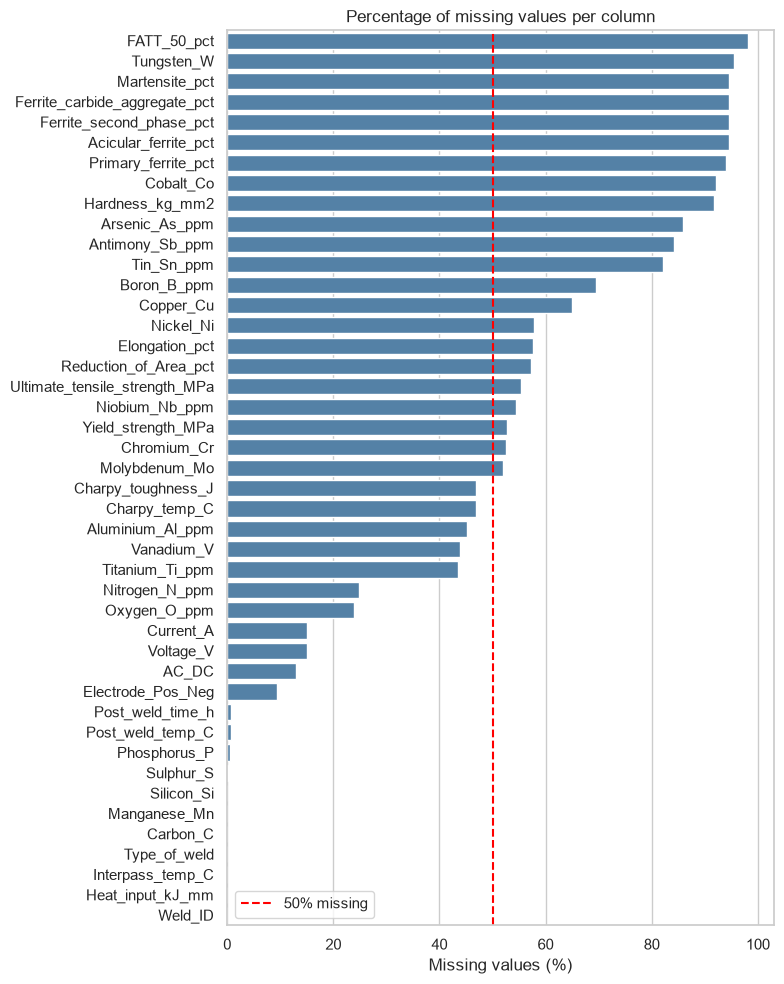

Rows with at least one missing value: 1652 / 1652
Rows with no missing value:           0 / 1652


In [76]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.axvline(50, color="red", linestyle="--", label="50% missing")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.title("Percentage of missing values per column")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rows with at least one missing value: {df.isna().any(axis=1).sum()} / {len(df)}")
print(f"Rows with no missing value:           {(~df.isna().any(axis=1)).sum()} / {len(df)}")

### 1.4 Descriptive statistics

For this summary only, we build a temporary numeric copy of the data (`df_num`) where non-convertible entries become NaN. The original `df` is left untouched.

In [77]:
df_num = df.copy()
for col in numeric_candidates:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

df_num[numeric_candidates].describe().T

,count,mean,std,min,25%,50%,75%,max
Carbon_C,1652.0,0.075521,0.023898,0.029,0.06175,0.074,0.086,0.18
Silicon_Si,1652.0,0.328577,0.112455,0.040,0.27000,0.320,0.360,1.14
Manganese_Mn,1652.0,1.202821,0.382137,0.270,0.94000,1.270,1.440,2.25
Sulphur_S,1641.0,0.009561,0.011239,0.001,0.00600,0.007,0.010,0.14
Phosphorus_P,1642.0,0.012952,0.019627,0.002,0.00700,0.010,0.014,0.25
Nickel_Ni,697.0,0.415034,0.786951,0.000,0.00000,0.067,0.260,3.50
Chromium_Cr,784.0,2.101273,3.026548,0.000,0.00000,0.530,2.300,10.20
Molybdenum_Mo,791.0,0.480358,0.477423,0.000,0.00000,0.340,1.010,1.50
Vanadium_V,620.0,0.072443,0.096364,0.000,0.00400,0.015,0.180,0.32
Copper_Cu,564.0,0.176188,0.325897,0.000,0.00000,0.030,0.190,1.63


### 1.5 Distributions of numerical variables

We look for skewness, outliers and suspicious repeated values (sentinel or default values).

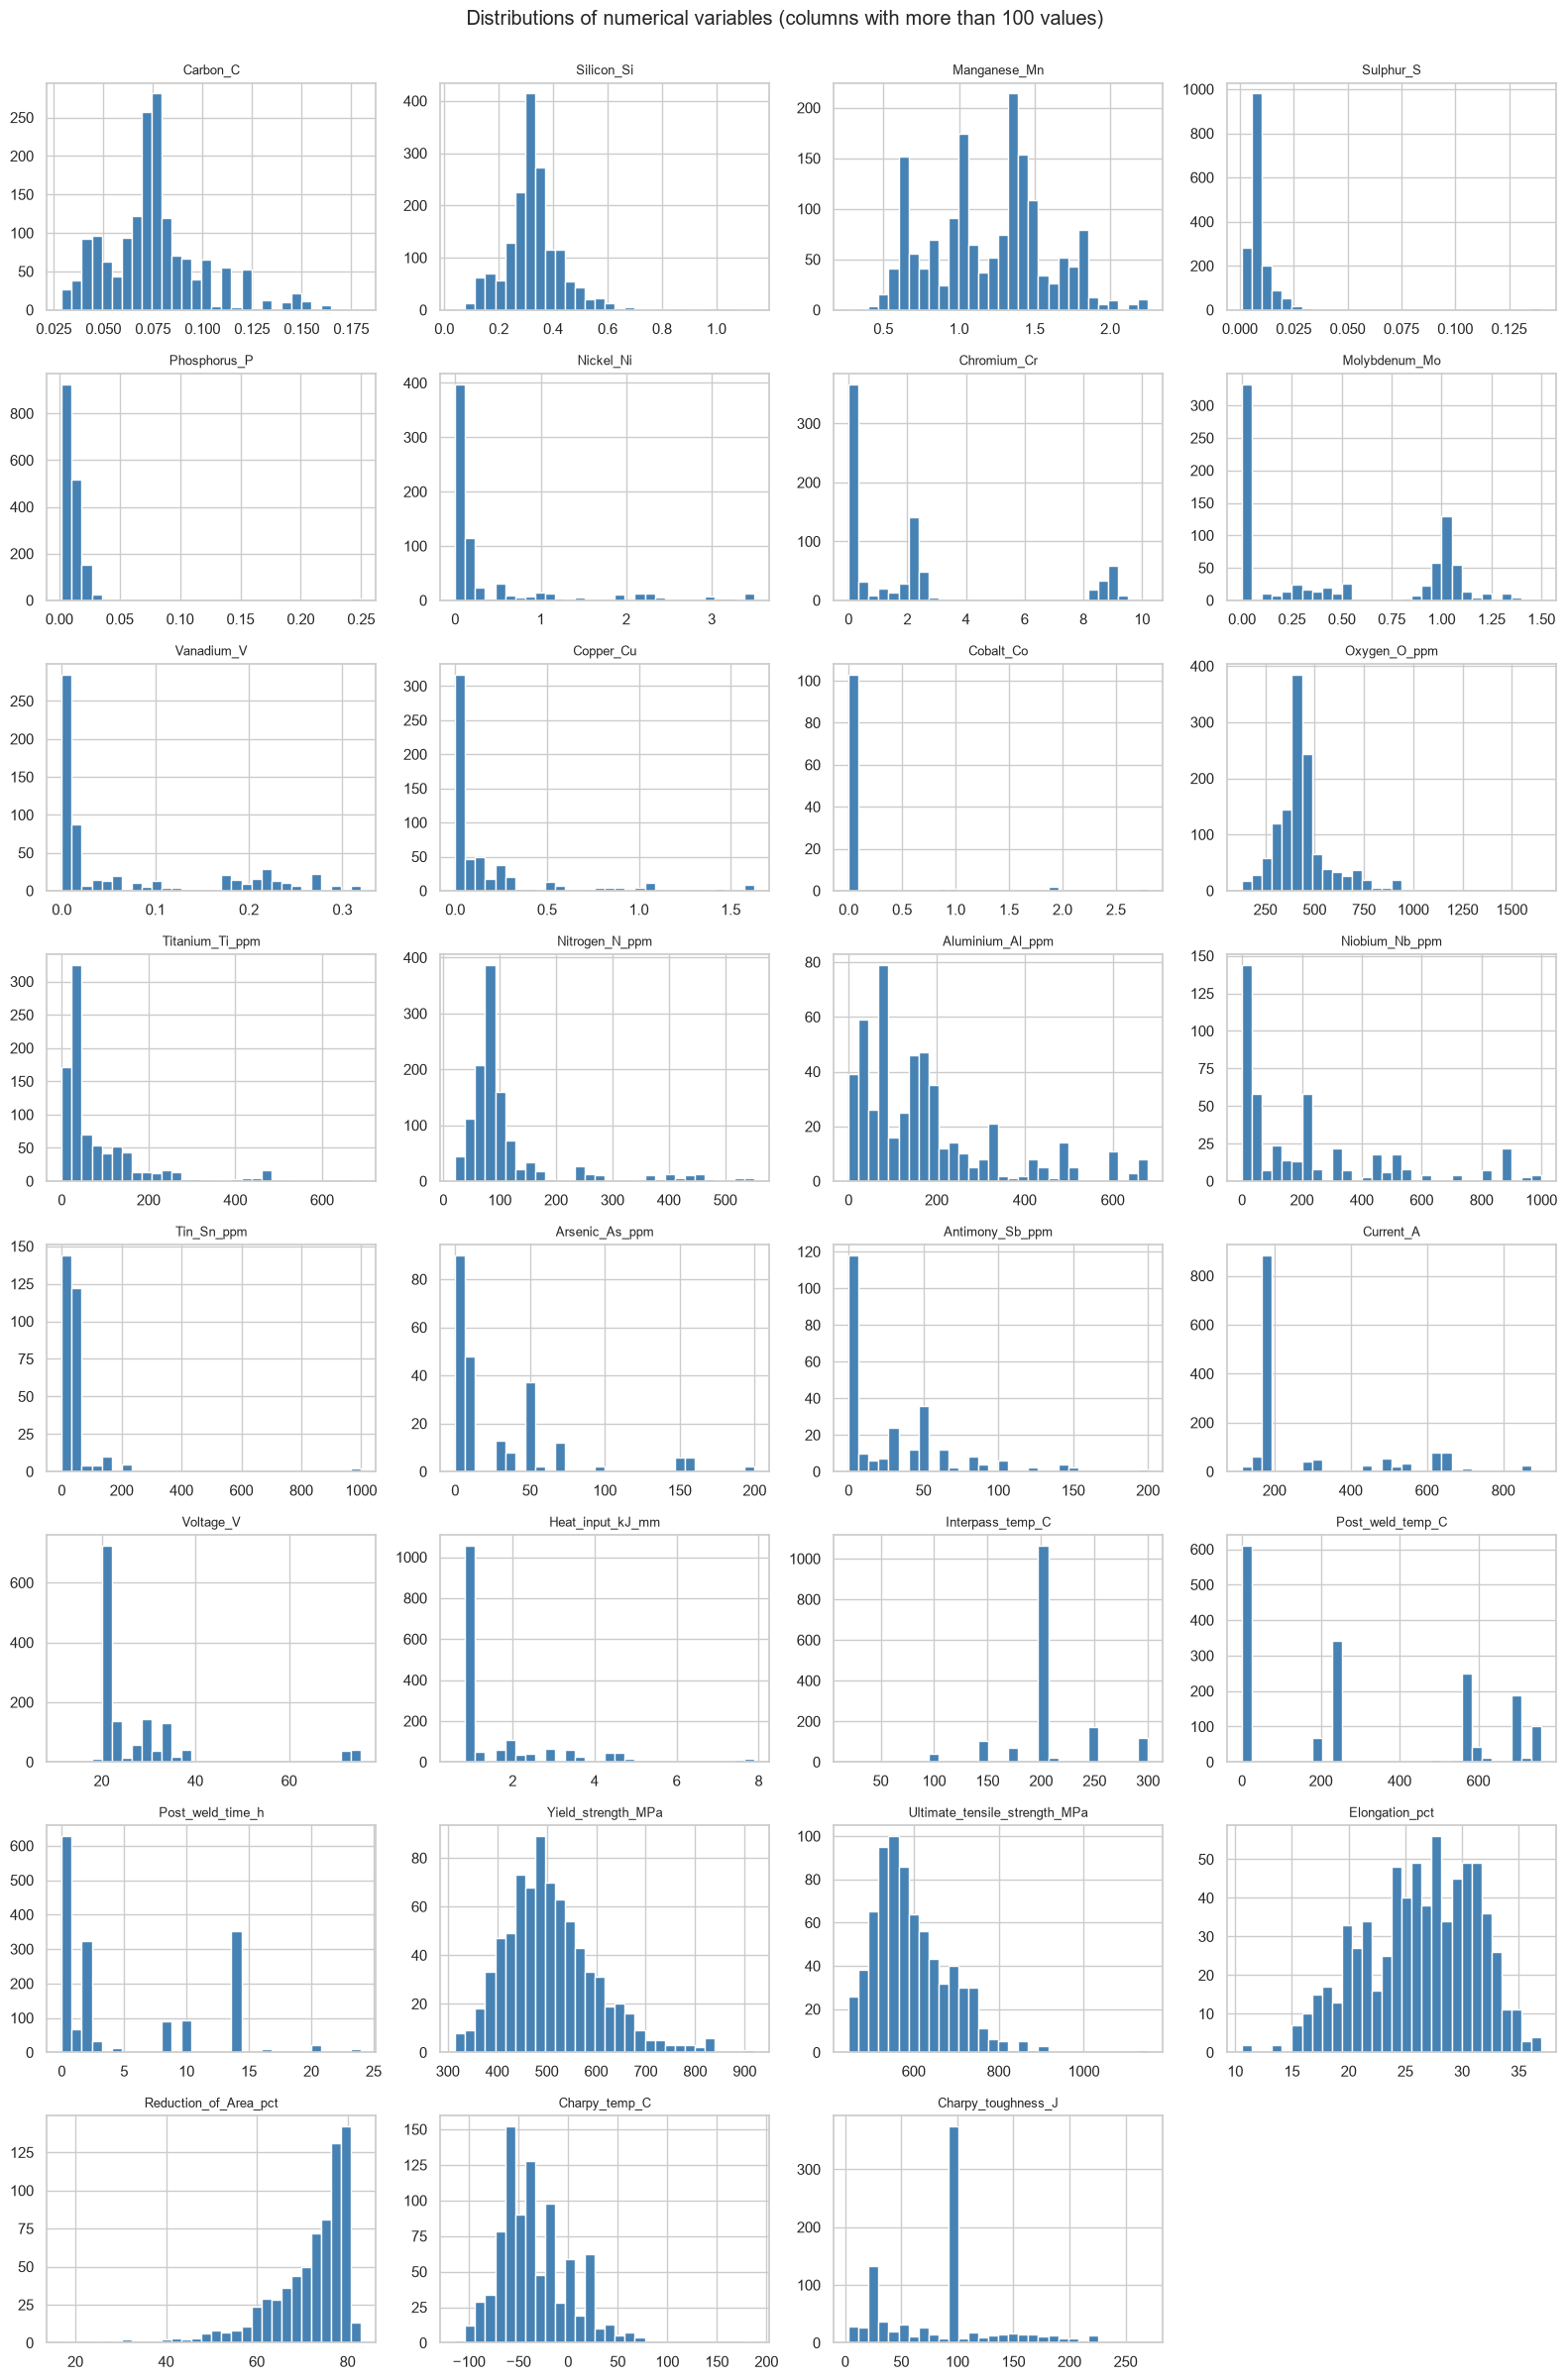

In [78]:
plot_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 100]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df_num[col].dropna(), bins=30, color="steelblue")
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
plt.suptitle("Distributions of numerical variables (columns with more than 100 values)", y=1.0)
plt.tight_layout()
plt.show()

### 1.6 Categorical variables

In [79]:
for col in ["Type_of_weld", "AC_DC", "Electrode_Pos_Neg"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string(), "\n")

--- Type_of_weld ---
Type_of_weld
MMA      1140
SA        261
FCA        87
TSA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GTAA        4
GMAA        4 

--- AC_DC ---
AC_DC
DC     1395
NaN     215
AC       42 

--- Electrode_Pos_Neg ---
Electrode_Pos_Neg
+      1451
NaN     156
0        38
-         7 



### 1.7 Candidate target variables

The project asks us to identify which variables represent weld quality. The main candidates are the mechanical properties. We compare how many measurements each one has and how they are distributed.

,n_values,pct_missing,min,median,max
Charpy_toughness_J,879,46.8,3.0,100.0,270.0
Yield_strength_MPa,780,52.8,315.0,495.0,920.0
Ultimate_tensile_strength_MPa,738,55.3,447.0,575.5,1151.0
Elongation_pct,700,57.6,10.6,26.8,37.0
Reduction_of_Area_pct,705,57.3,17.0,75.0,83.0
Hardness_kg_mm2,80,95.2,154.0,221.0,265.0


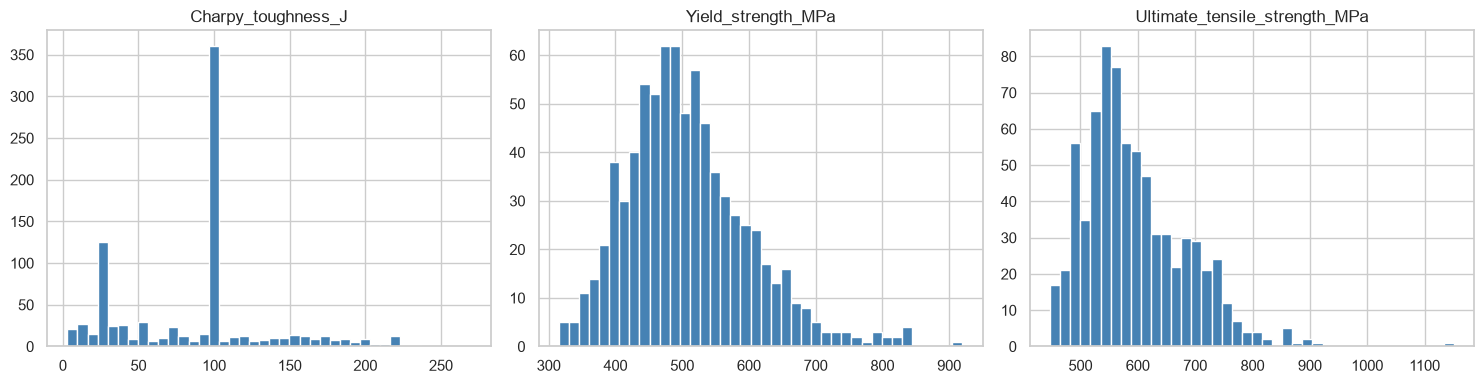

In [80]:
target_candidates = [
    "Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Hardness_kg_mm2",
]

summary = pd.DataFrame({
    "n_values": df_num[target_candidates].notna().sum(),
    "pct_missing": (df_num[target_candidates].isna().mean() * 100).round(1),
    "min": df_num[target_candidates].min(),
    "median": df_num[target_candidates].median(),
    "max": df_num[target_candidates].max(),
})
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa"]):
    ax.hist(df_num[col].dropna(), bins=40, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Charpy_toughness_J` is the energy absorbed by the weld during an impact test, but it depends on the temperature at which the test was done (`Charpy_temp_C`). Below we check that dependence and how many tests were done at each temperature.

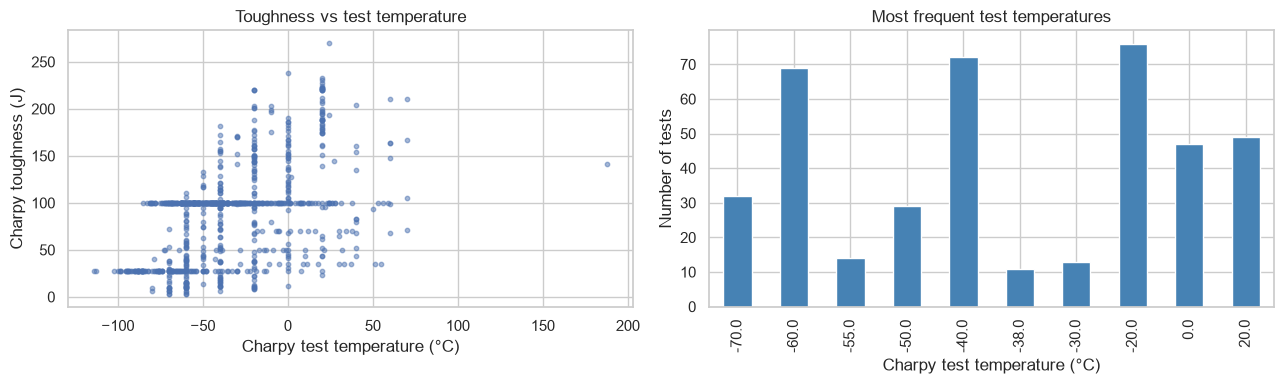

Most frequent toughness values:
Charpy_toughness_J
100.0    356
28.0     118
50.0      16
35.0      12
70.0      12


In [81]:
charpy = df_num[["Charpy_temp_C", "Charpy_toughness_J"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(charpy["Charpy_temp_C"], charpy["Charpy_toughness_J"], s=10, alpha=0.5)
axes[0].set_xlabel("Charpy test temperature (°C)")
axes[0].set_ylabel("Charpy toughness (J)")
axes[0].set_title("Toughness vs test temperature")

charpy["Charpy_temp_C"].value_counts().head(10).sort_index().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_xlabel("Charpy test temperature (°C)")
axes[1].set_ylabel("Number of tests")
axes[1].set_title("Most frequent test temperatures")
plt.tight_layout()
plt.show()

print("Most frequent toughness values:")
print(charpy["Charpy_toughness_J"].value_counts().head(5).to_string())

### 1.8 Correlations

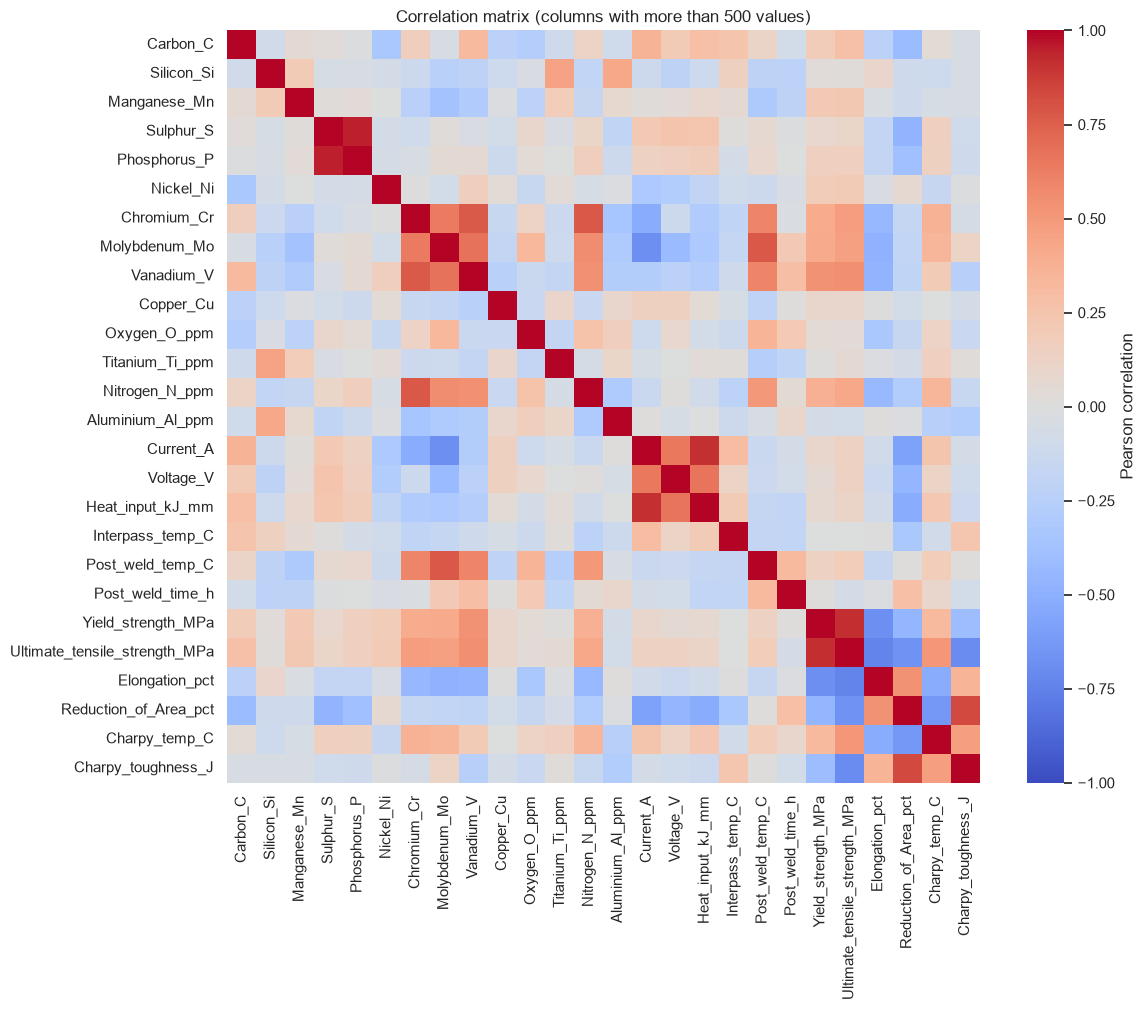

In [82]:
corr_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 500]
corr = df_num[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix (columns with more than 500 values)")
plt.tight_layout()
plt.show()

### 1.9 Duplicates and weld groups

Several rows can belong to the same weld (same composition and process, different test conditions). This matters for validation: if rows of the same weld land in both train and test sets, the performance is overestimated.

In [83]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Unique Weld_ID values: {df['Weld_ID'].nunique()} / {len(df)}")

# Same composition and process parameters shared by several rows
composition_cols = ["Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
                    "Current_A", "Voltage_V", "Heat_input_kJ_mm"]
group_sizes = df.groupby(composition_cols, dropna=False).size()
print(f"Distinct composition/process combinations: {len(group_sizes)}")
print(f"Rows per combination: median {group_sizes.median():.0f}, max {group_sizes.max()}")

Fully duplicated rows: 0
Unique Weld_ID values: 1490 / 1652
Distinct composition/process combinations: 609
Rows per combination: median 2, max 20


## Phase 2: Preprocessing

Every step below is justified from what we observed in Phase 1. The preprocessing is split in two parts:
- **Deterministic cleaning** (2.1 to 2.4): rules that do not learn anything from the data (parsing strings, choosing columns, defining targets). It is safe to apply it to the whole dataset.
- **Learned transformations** (2.5): imputation, scaling and encoding. They learn parameters (medians, means, categories), so they are wrapped in a scikit-learn `ColumnTransformer` that will be fitted **only on the training folds** during cross-validation, to avoid data leakage.

### 2.1 Cleaning non-standard values

From section 1.2, the non-numeric entries follow four patterns. We convert each one to a number:

| Pattern | Example | Meaning | Treatment |
|---|---|---|---|
| `<x` | `<5`, `<0.0005` | element below the detection limit | half of the limit (`x/2`) |
| `<x` in a `_ppm` column with x < 1 | `<0.01` in `Titanium_Ti_ppm` | the limit is expressed in wt% instead of ppm | convert wt% to ppm (x 10000), then half |
| range `a-b` | `150-200` | interpass temperature range | midpoint |
| number followed by text | `66totndres`, `203(Hv30)` | total value followed by a label | leading number |

Setting detection-limit values to half of the limit is a common convention: it keeps the information "present, but very small" instead of discarding the value or treating it as a missing measurement.

In [84]:
import re


def parse_value(x, col):
    """Convert a raw entry of the weld database to a float (NaN if impossible)."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    try:
        return float(s)
    except ValueError:
        pass
    m = re.fullmatch(r"<\s*([\d.]+)", s)               # detection limit
    if m:
        limit = float(m.group(1))
        if col.endswith("_ppm") and limit < 1:           # limit given in wt% in a ppm column
            limit *= 10000
        return limit / 2
    m = re.fullmatch(r"([\d.]+)-([\d.]+)", s)           # range
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    m = re.match(r"([\d.]+)", s)                         # number followed by text
    if m:
        return float(m.group(1))
    return np.nan


df_clean = df.copy()
for col in numeric_candidates:
    df_clean[col] = df_clean[col].map(lambda x: parse_value(x, col))

# Sanity check: parsing must not create new missing values
new_nans = (df_clean[numeric_candidates].isna().sum() - df[numeric_candidates].isna().sum())
print("New NaN introduced by the parsing:", int(new_nans.sum()))
print("Columns still stored as strings:", [c for c in numeric_candidates if df_clean[c].dtype == object or str(df_clean[c].dtype) == "str"])

New NaN introduced by the parsing: 0
Columns still stored as strings: []


### 2.2 Features and quality variables

The preprocessing below is **independent of the choice of the quality variables**: that choice is made after the PCA, once we understand the structure of the data. For this reason:

- All the welds are kept (no row is removed because a target is missing).
- The measurements that could represent quality (mechanical properties) stay in `df_clean`, untouched and out of the features. The candidates are listed in `candidate_quality_cols`.
- `Charpy_temp_C` is not a feature for now: it is the temperature of the Charpy test, not a property of the weld. If toughness is chosen as a quality variable, it will have to be considered explicitly (it changes the toughness strongly).

### 2.3 Feature selection

- **Kept:** chemical composition and welding process parameters (the first 30 columns): they are known before the weld is tested.
- **Not features, because they are measured after welding** (they are results of the weld, not inputs, and would leak the quality): mechanical properties, hardness, FATT50 and microstructure.
- **Removed because they are almost empty:** columns with more than 80% missing values (Co, W, Sn, As, Sb). Imputing so many values would mostly invent data.
- **`Weld_ID`** is not a feature: it is an identifier.
- **Weld groups.** Rows with identical composition and process parameters are tests of the same weld. We build a group id so that cross-validation can keep them in the same fold (`GroupKFold`).
- **Rare weld types** (not MMA, SA, FCA, TSA, ShMA) are grouped into `Other`, because categories with fewer than 20 rows are too small to be useful.

In [85]:
MAX_MISSING = 0.80          # drop features with more than 80% missing values

# Composition and process parameters: first 30 columns (Carbon_C ... Post_weld_time_h)
weld_features = list(df_clean.columns[:30])
missing_ratio = df_clean[weld_features].isna().mean()
dropped_features = missing_ratio[missing_ratio > MAX_MISSING].index.tolist()
features = [c for c in weld_features if c not in dropped_features]

print(f"Dropped for more than {MAX_MISSING:.0%} missing values: {dropped_features}")
print(f"Kept {len(features)} features: {features}")

# Group id: same composition and process parameters = same weld
group_cols = ["Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
              "Current_A", "Voltage_V", "Heat_input_kJ_mm"]
df_clean["Group"] = df_clean.groupby(group_cols, dropna=False).ngroup()

# Rare weld types (fewer than 20 rows) are grouped into "Other"
main_welds = ["MMA", "SA", "FCA", "TSA", "ShMA"]
df_clean["Type_of_weld"] = df_clean["Type_of_weld"].where(df_clean["Type_of_weld"].isin(main_welds), "Other")

# Candidate quality variables: kept aside, to be chosen after the PCA
candidate_quality_cols = [
    "Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Hardness_kg_mm2",
]

Dropped for more than 80% missing values: ['Cobalt_Co', 'Tungsten_W', 'Tin_Sn_ppm', 'Arsenic_As_ppm', 'Antimony_Sb_ppm']
Kept 25 features: ['Carbon_C', 'Silicon_Si', 'Manganese_Mn', 'Sulphur_S', 'Phosphorus_P', 'Nickel_Ni', 'Chromium_Cr', 'Molybdenum_Mo', 'Vanadium_V', 'Copper_Cu', 'Oxygen_O_ppm', 'Titanium_Ti_ppm', 'Nitrogen_N_ppm', 'Aluminium_Al_ppm', 'Boron_B_ppm', 'Niobium_Nb_ppm', 'Current_A', 'Voltage_V', 'AC_DC', 'Electrode_Pos_Neg', 'Heat_input_kJ_mm', 'Interpass_temp_C', 'Type_of_weld', 'Post_weld_temp_C', 'Post_weld_time_h']


### 2.4 Feature matrix

`X` contains the features of **all** the welds. The candidate quality variables are not part of it. Once the quality variables are chosen, the rows where they are available are the labeled data, and the others are the unlabeled data of the semi-supervised part.

In [86]:
X = df_clean[features]
groups = df_clean["Group"]

print(f"X: {X.shape[0]} welds x {X.shape[1]} features, {groups.nunique()} weld groups")

# Availability of each candidate quality variable (information only, no row is removed)
pd.DataFrame({
    "n_values": df_clean[candidate_quality_cols].notna().sum(),
    "pct_missing": (df_clean[candidate_quality_cols].isna().mean() * 100).round(1),
})

X: 1652 welds x 25 features, 609 weld groups


,n_values,pct_missing
Charpy_toughness_J,879,46.8
Yield_strength_MPa,780,52.8
Ultimate_tensile_strength_MPa,738,55.3
Elongation_pct,700,57.6
Reduction_of_Area_pct,705,57.3
Hardness_kg_mm2,138,91.6


### 2.5 Missing values, categorical variables and scaling

These steps learn parameters from the data, so they are defined here as an unfitted `ColumnTransformer` and will be fitted inside the cross-validation of the models.

**Missing values**
- *Alloying elements* (`Nickel_Ni`, `Chromium_Cr`, `Molybdenum_Mo`, `Copper_Cu`): they are mostly absent in plain carbon-manganese steels, so a missing value most likely means "not added". They are filled with **0**.
- *Other numerical variables*: filled with the **median** (robust to the skewed distributions seen in section 1.5).
- In both cases a **missing indicator** column is added, so a model can still use the fact that a value was not reported.
- *Categorical variables*: missing values become their own category `missing`.

**Categorical variables.** `AC_DC`, `Electrode_Pos_Neg` and `Type_of_weld` are **one-hot encoded** (they have no natural order); unseen categories at prediction time are ignored.

**Scaling.** Variables have very different units and ranges (wt%, ppm, A, V, °C, kJ/mm), so we apply **standardization (z-score)**. It is required for PCA and for distance-based or linear models (KNN, SVM, linear regression, label propagation). Tree-based models do not need it, but it does no harm and lets us use the same preprocessing for every model. Skewed variables are not log-transformed, to keep the variables easy to interpret.

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

alloy_cols_all = ["Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Copper_Cu"]
categorical_features_all = ["AC_DC", "Electrode_Pos_Neg", "Type_of_weld"]


def make_preprocessor(feature_list):
    alloy = [c for c in alloy_cols_all if c in feature_list]
    categorical = [c for c in categorical_features_all if c in feature_list]
    numeric = [c for c in feature_list if c not in alloy + categorical]
    return ColumnTransformer([
        ("alloy", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)),
            ("scale", StandardScaler()),
        ]), alloy),
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), numeric),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical),
    ]).set_output(transform="pandas")


preprocessor = make_preprocessor(features)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('alloy', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

### 2.6 Check of the preprocessing

To verify that the pipeline works we fit it on all the welds. **This is only an inspection** (and the input of the PCA, which is exploratory): when models are evaluated, the pipeline must be fitted on the training folds only.

In [88]:
X_t = preprocessor.fit_transform(X)

print(f"{X.shape[1]} raw features -> {X_t.shape[1]} columns after preprocessing")
print(f"Remaining NaN: {int(X_t.isna().sum().sum())}")

X_t.describe().T[["mean", "std", "min", "max"]].round(2).head(12)

25 raw features -> 52 columns after preprocessing
Remaining NaN: 0


,mean,std,min,max
alloy__Nickel_Ni,-0.0,1.0,-0.32,6.04
alloy__Chromium_Cr,-0.0,1.0,-0.43,3.94
alloy__Molybdenum_Mo,-0.0,1.0,-0.56,3.11
alloy__Copper_Cu,-0.0,1.0,-0.29,7.56
alloy__missingindicator_Nickel_Ni,0.0,1.0,-1.17,0.85
alloy__missingindicator_Chromium_Cr,0.0,1.0,-1.05,0.95
alloy__missingindicator_Molybdenum_Mo,-0.0,1.0,-1.04,0.96
alloy__missingindicator_Copper_Cu,-0.0,1.0,-1.36,0.73
numeric__Carbon_C,0.0,1.0,-1.95,4.37
numeric__Silicon_Si,-0.0,1.0,-2.57,7.22


## Phase 3: Principal Component Analysis (PCA)

The PCA is used to build intuition about the structure of the data, not to evaluate any model. It does not use any target, so it is applied to **all** the welds, on the preprocessed matrix `X_t`. It needs the three properties that the preprocessing provides: no missing values, only numbers, and a common scale (otherwise the variables with large numbers, such as the current, would dominate).

### 3.1 Input of the PCA and explained variance

`X_t` has 52 columns of three kinds: scaled numerical variables, missing indicators (0/1) and one-hot categories (0/1). The binary columns describe *which information was reported* or *which category a weld belongs to*, not a physical quantity. We therefore fit the PCA twice and compare:

- **All columns** (52).
- **Numerical and alloy variables only** (22): the physical measurements (composition and process parameters), without indicators and categories.

In [89]:
from sklearn.decomposition import PCA

numeric_cols = [c for c in X_t.columns
                if c.startswith(("alloy__", "numeric__")) and "missingindicator" not in c]
X_pca_all = X_t
X_pca_num = X_t[numeric_cols]

pca_all = PCA().fit(X_pca_all)
pca_num = PCA().fit(X_pca_num)


def n_components_for(pca, threshold):
    return int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= threshold)) + 1


pd.DataFrame({
    "n_columns": [X_pca_all.shape[1], X_pca_num.shape[1]],
    "PC1 (%)": [pca_all.explained_variance_ratio_[0] * 100, pca_num.explained_variance_ratio_[0] * 100],
    "PC2 (%)": [pca_all.explained_variance_ratio_[1] * 100, pca_num.explained_variance_ratio_[1] * 100],
    "PC1+PC2 (%)": [pca_all.explained_variance_ratio_[:2].sum() * 100, pca_num.explained_variance_ratio_[:2].sum() * 100],
    "components for 80%": [n_components_for(pca_all, 0.80), n_components_for(pca_num, 0.80)],
    "components for 90%": [n_components_for(pca_all, 0.90), n_components_for(pca_num, 0.90)],
}, index=["All columns", "Numerical and alloy only"]).round(1)

,n_columns,PC1 (%),PC2 (%),PC1+PC2 (%),components for 80%,components for 90%
All columns,52,15.8,11.4,27.2,14,20
Numerical and alloy only,22,18.2,14.2,32.4,11,15


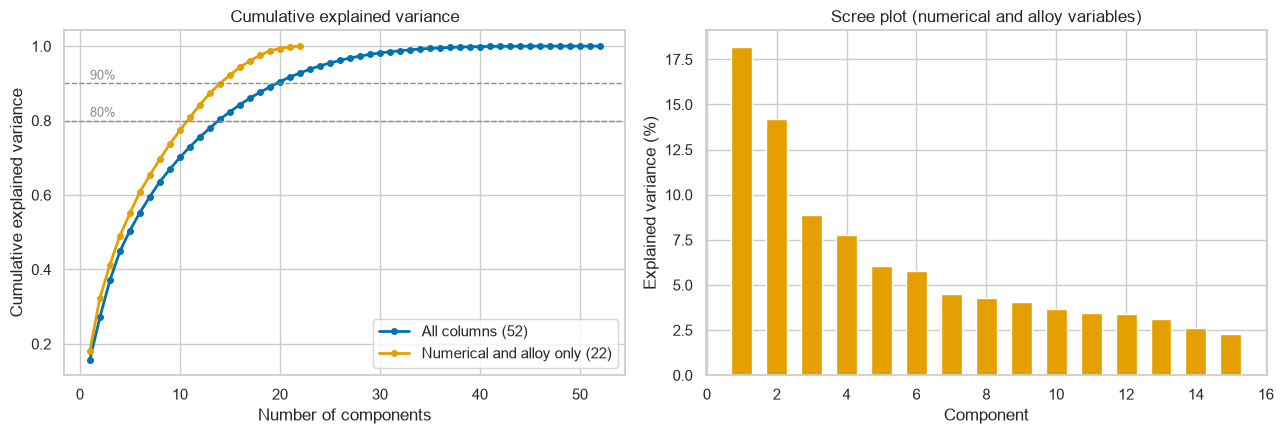

In [90]:
BLUE, ORANGE, GREY = "#0072B2", "#E69F00", "#8c8c8c"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for pca, label, color in [(pca_all, f"All columns ({X_pca_all.shape[1]})", BLUE),
                          (pca_num, f"Numerical and alloy only ({X_pca_num.shape[1]})", ORANGE)]:
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    axes[0].plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=4, linewidth=2,
                 color=color, label=label)
for threshold in (0.80, 0.90):
    axes[0].axhline(threshold, color=GREY, linestyle="--", linewidth=1)
    axes[0].text(1, threshold + 0.01, f"{threshold:.0%}", color=GREY, fontsize=9)
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("Cumulative explained variance")
axes[0].legend(loc="lower right")

n_show = 15
axes[1].bar(range(1, n_show + 1), pca_num.explained_variance_ratio_[:n_show] * 100, color=ORANGE, width=0.6)
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Explained variance (%)")
axes[1].set_title("Scree plot (numerical and alloy variables)")

plt.tight_layout()
plt.show()

### 3.2 Welds in the plane of the first two components

From here on we use the numerical and alloy version, which is the one that can be interpreted physically. The same plane is colored four ways: by weld type, by two candidate quality variables (yield strength and Charpy toughness) and by whether the heat input is exactly 1.0 kJ/mm. Welds without a measurement are shown in grey. The quality variables are used here only as colors: the choice of the quality variables is made later.

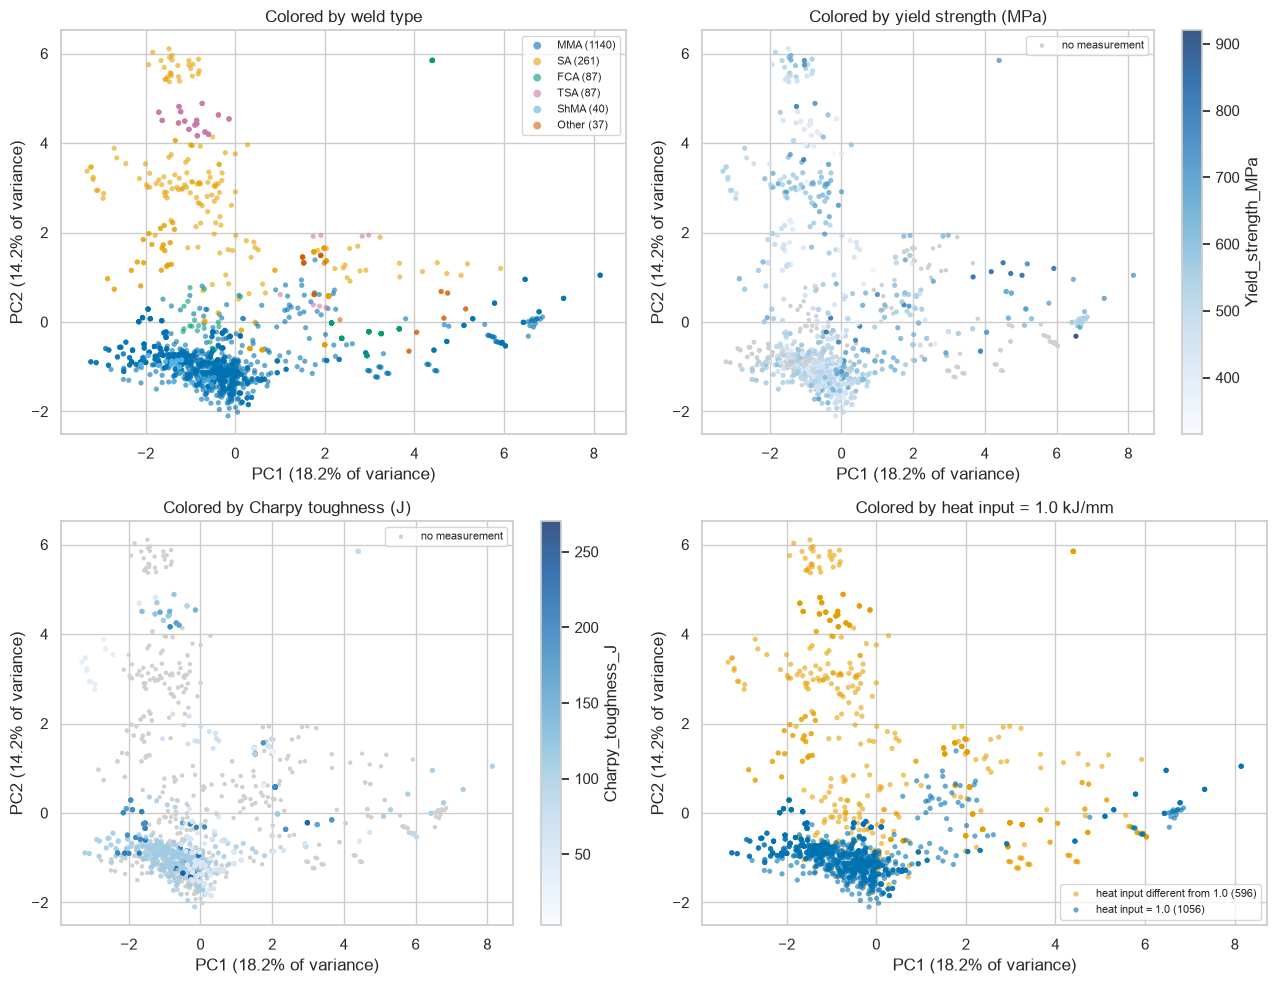

In [91]:
Z = pd.DataFrame(pca_num.transform(X_pca_num)[:, :4], columns=["PC1", "PC2", "PC3", "PC4"], index=X_t.index)
var_pct = pca_num.explained_variance_ratio_ * 100

weld_order = main_welds + ["Other"]
weld_colors = dict(zip(weld_order, ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# a) weld type
ax = axes[0, 0]
for weld in weld_order:
    mask = df_clean["Type_of_weld"] == weld
    ax.scatter(Z.loc[mask, "PC1"], Z.loc[mask, "PC2"], s=14, alpha=0.6, color=weld_colors[weld],
               label=f"{weld} ({mask.sum()})", edgecolor="none")
ax.set_title("Colored by weld type")
ax.legend(fontsize=8, markerscale=1.5)

# b) and c) continuous candidate quality variables
for ax, col, title in [(axes[0, 1], "Yield_strength_MPa", "Colored by yield strength (MPa)"),
                       (axes[1, 0], "Charpy_toughness_J", "Colored by Charpy toughness (J)")]:
    has_value = df_clean[col].notna()
    ax.scatter(Z.loc[~has_value, "PC1"], Z.loc[~has_value, "PC2"], s=10, color="#d0d0d0", edgecolor="none",
               label="no measurement")
    sc = ax.scatter(Z.loc[has_value, "PC1"], Z.loc[has_value, "PC2"], s=14, c=df_clean.loc[has_value, col],
                    cmap="Blues", edgecolor="none", alpha=0.8)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")

# d) heat input equal to 1.0
ax = axes[1, 1]
is_one = df_clean["Heat_input_kJ_mm"] == 1.0
ax.scatter(Z.loc[~is_one, "PC1"], Z.loc[~is_one, "PC2"], s=14, alpha=0.6, color=ORANGE, edgecolor="none",
           label=f"heat input different from 1.0 ({(~is_one).sum()})")
ax.scatter(Z.loc[is_one, "PC1"], Z.loc[is_one, "PC2"], s=14, alpha=0.6, color=BLUE, edgecolor="none",
           label=f"heat input = 1.0 ({is_one.sum()})")
ax.set_title("Colored by heat input = 1.0 kJ/mm")
ax.legend(fontsize=8)

for ax in axes.ravel():
    ax.set_xlabel(f"PC1 ({var_pct[0]:.1f}% of variance)")
    ax.set_ylabel(f"PC2 ({var_pct[1]:.1f}% of variance)")
plt.tight_layout()
plt.show()

### 3.3 Loadings: what the components represent

The loadings are the weights of each original variable in a component. A large positive or negative weight means that the variable contributes strongly to it; variables with weights of the same sign move together along that component.

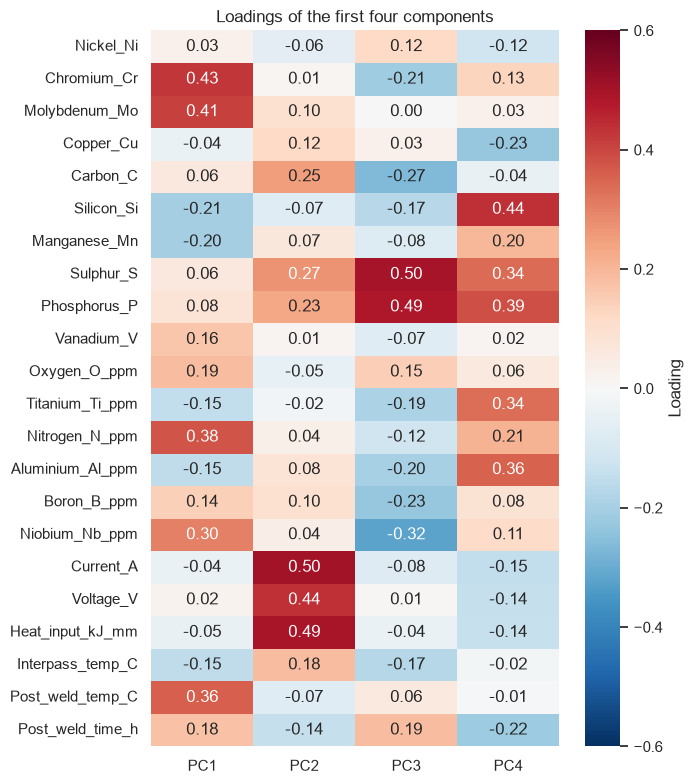

PC1: Chromium_Cr (+0.43), Molybdenum_Mo (+0.41), Nitrogen_N_ppm (+0.38), Post_weld_temp_C (+0.36), Niobium_Nb_ppm (+0.30)
PC2: Current_A (+0.50), Heat_input_kJ_mm (+0.49), Voltage_V (+0.44), Sulphur_S (+0.27), Carbon_C (+0.25)
PC3: Sulphur_S (+0.50), Phosphorus_P (+0.49), Niobium_Nb_ppm (-0.32), Carbon_C (-0.27), Boron_B_ppm (-0.23)
PC4: Silicon_Si (+0.44), Phosphorus_P (+0.39), Aluminium_Al_ppm (+0.36), Sulphur_S (+0.34), Titanium_Ti_ppm (+0.34)


In [92]:
feature_names = [c.split("__")[-1] for c in numeric_cols]
loadings = pd.DataFrame(pca_num.components_[:4].T, index=feature_names, columns=["PC1", "PC2", "PC3", "PC4"])

plt.figure(figsize=(7, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
            cbar_kws={"label": "Loading"})
plt.title("Loadings of the first four components")
plt.tight_layout()
plt.show()

for pc in loadings.columns:
    top = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index).head(5)
    print(f"{pc}: " + ", ".join(f"{name} ({value:+.2f})" for name, value in top.items()))

### 3.4 Link between the components and the candidate quality variables

Correlation of each component with the candidate quality variables and with the heat-input indicator. Each correlation uses only the welds where the variable is available, so the number of welds differs. These are linear correlations and are only indicative.

In [93]:
quality_for_pca = ["Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa", "Elongation_pct"]

rows = {}
for col in quality_for_pca:
    mask = df_clean[col].notna()
    rows[col] = {"n": int(mask.sum())} | {pc: np.corrcoef(Z.loc[mask, pc], df_clean.loc[mask, col])[0, 1]
                                          for pc in Z.columns}
rows["Heat input = 1.0 (indicator)"] = {"n": len(df_clean)} | {
    pc: np.corrcoef(Z[pc], (df_clean["Heat_input_kJ_mm"] == 1.0).astype(float))[0, 1] for pc in Z.columns}

pd.DataFrame(rows).T.round(2)

,n,PC1,PC2,PC3,PC4
Charpy_toughness_J,879.0,-0.12,-0.10,-0.03,-0.10
Yield_strength_MPa,780.0,0.31,0.14,-0.19,0.17
Ultimate_tensile_strength_MPa,738.0,0.37,0.22,-0.25,0.19
Elongation_pct,700.0,-0.43,-0.17,0.14,-0.15
Heat input = 1.0 (indicator),1652.0,-0.21,-0.66,-0.06,0.05


### 3.5 Interpretation

**Dimensionality.** There is no dominant direction: the first two components explain only about 32% of the variance, and 11 components (out of 22) are needed for 80% and 15 for 90%. The data are not low-dimensional, so the PCA is not useful to reduce the number of features here; it is useful to understand the structure.

**Missing indicators.** When they are included, the first components are dominated by the missing indicators: the PCA mostly separates welds by *which elements were reported* (different studies report different elements), not by metallurgy. This is why the interpretation uses only the numerical and alloy variables.

**What the components represent** (numerical and alloy version):
- **PC1 (about 18%): alloy content and heat treatment.** Chromium, molybdenum, nitrogen, niobium and post-weld temperature on one side; silicon and manganese on the other. FCA welds and the rare weld types are high on this component.
- **PC2 (about 14%): welding energy.** Current, heat input and voltage. Submerged-arc welds (SA, TSA) are high, manual welds (MMA, ShMA) are low.
- **PC3 (about 9%): impurities.** Sulphur and phosphorus, which vary together (correlation 0.95 in the EDA).
- **PC4 (about 8%):** silicon, phosphorus, aluminium, sulphur and titanium.

The weld families separate in the PC1-PC2 plane. This supports using `GroupKFold` and suggests that a model may learn the weld family rather than the effect of the variables.

**Heat input.** The indicator "heat input = 1.0" has a correlation of about -0.66 with PC2: the value 1.0 is the manual-welding side of the energy axis, so it is largely redundant with the weld type. It still carries information for the other processes (values such as 2.0, 3.3, 4.6), so it is kept for now; the decision can be revisited with the team.

**Link with quality (indicative).** Strength and elongation are related to PC1 (yield +0.31, tensile +0.37, elongation -0.43): more alloyed and heat-treated welds are stronger and less ductile, which is the strength/ductility trade-off already seen in the EDA. Charpy toughness is only weakly related to any of the first four components (largest absolute correlation about 0.12): toughness is not explained by the main directions of variance of composition and process. This suggests that toughness is harder to predict from these variables (probably non-linear relations and interactions, plus the effect of the test temperature and of the 28 J values), whereas strength and elongation have a clearer link with composition.

**Consequences for the next steps.**
- Standardization is justified: without it the current and the voltage would dominate the first components.
- The quality variables will be chosen taking this into account: the strength variables are better linked to the features than the toughness.
- The PCA components are not used as inputs of the models; the original variables are kept for interpretability.

## Phase 4: Quality variables and prediction strategy

### 4.1 What represents weld quality

A good weld has to be **strong** and **tough** at the same time. These are two different properties, measured with different tests, and they move in opposite directions: the correlation between Charpy toughness and tensile strength is -0.70 (and -0.41 with yield strength). A single number cannot describe quality, so we define quality along **two dimensions**, each with its own variables and its own model:

| Dimension | Quality variables | Role |
|---|---|---|
| **Strength** (main) | `Yield_strength_MPa`, `Ultimate_tensile_strength_MPa`, `Elongation_pct` | Main objective |
| **Toughness** (secondary) | `Charpy_toughness_J` | Second objective |

### 4.2 Why these variables

**Strength is the main objective** because the data support it best:
- 665 welds have the three measurements together, belonging to 465 independent weld groups.
- The three variables are strongly related (yield-tensile 0.91, yield-elongation -0.71, tensile-elongation -0.74), so predicting them together in one multi-target model is natural. Yield and tensile strength measure the resistance; elongation measures the ductility and shows the strength/ductility trade-off.
- There is no test-temperature effect and no suspicious repeated value.
- The PCA shows a clear link with composition: they are related to PC1, the alloy content and heat treatment axis (yield +0.31, tensile +0.37, elongation -0.43).

**Toughness is the secondary objective** because it is the standard criterion of weld quality (resistance to brittle fracture, relevant for the cold-weather applications of the project, such as wind turbine tubes), but it is harder to model:
- Toughness depends strongly on the test temperature (median 39 J at -60 °C, 188 J at +20 °C), so `Charpy_temp_C` must be taken into account.
- 356 of the 879 values are exactly 100 J at every test temperature, which is physically implausible (probably a default value); 118 values are 28 J, concentrated at low temperatures (probably an acceptance threshold). If the 100 J values are removed, 523 welds remain (200 independent groups), and 23% of them are 28 J.
- In the PCA it is only weakly related to the main components (largest absolute correlation 0.12): it is not explained by the main directions of variance of composition and process. We expect weaker results than for strength.

### 4.3 Why two models and not one

Charpy and strength are measured on almost disjoint sets of welds: only 144 welds have Charpy, yield and tensile together (35 if the Charpy temperature is also fixed). A single multi-target model would keep less than 10% of the data. Two models let each one use all the welds where its own variables are available, and the two predictions can still be compared to discuss the strength/toughness trade-off.

### 4.4 What is discarded, and why

- **Hardness** (80 values) and the **microstructure** variables and FATT50 (fewer than 100 values): too few measurements.
- **Reduction of area** (705 values): it is a result of the same tensile test and correlates 0.83 with Charpy toughness; it is not an input and does not add a different quality dimension.
- **Weld_ID** and **Group**: identifiers, not variables.

### 4.5 Prediction strategy

1. **Features:** the 25 composition and process variables, preprocessed by `preprocessor` (Phase 2). For the toughness model, `Charpy_temp_C` is added as a feature, because it is a known condition of the test and changes the result strongly.
2. **Strength model:** multi-target regression of the three variables on the 665 welds that have all of them.
3. **Toughness model:** regression of `Charpy_toughness_J` on the welds with a Charpy value and a test temperature. The treatment of the 100 J and 28 J values is **still to be decided** (and checked against the documentation of the database): options are to remove only the 100 J values, to remove both, or to move to a classification (toughness above or below a threshold).
4. **Validation:** cross-validation with `GroupKFold` on the `Group` column (welds with identical composition and process parameters stay in the same fold). Without it, rows of the same weld would appear in the training and test sets and the scores would be overestimated. The preprocessing must be inside a `Pipeline`, so that it is fitted on the training folds only.
5. **Metrics:** R², RMSE and MAE for each target. The targets have different units, so they are evaluated separately.
6. **Unlabeled data:** the welds without the quality measurements (about 840 without any strength measurement and about 770 without Charpy) have all the input features and are the material for the semi-supervised part. Their distribution differs from the labeled welds (for example, nickel is more frequent and higher among them), so pseudo-labels on nickel-rich welds are extrapolations.

### 4.6 Limitations to keep in mind

- Only 465 (strength) and about 200 (toughness) independent welds: cross-validation estimates will be noisy and complex models are risky.
- The weld types are unbalanced (about 70% of the strength data are MMA welds): a model may learn the weld family rather than the effect of the variables.
- The values 100 J and 28 J in the Charpy data are not real measurements and may bias the toughness model.
- Linear correlations and the PCA only describe linear structure; the relations with the quality variables are probably non-linear.

# Modélisation et validation 

Nous reprenons les deux tâches définies par Nico : prédire les propriétés mécaniques de la soudure, puis son énergie Charpy à une température d’essai connue. Les modèles, leur validation et la méthode semi-supervisée sont présentés ci-dessous. Les résultats serviront ensuite à la comparaison des approches.

Cette section vient après les 47 cellules de Nico, conservées sans modification. Le code et les références sont inclus dans ce notebook. Il utilise seulement le dossier `data` de Nico.

## 5.1 Préparation des données

Nous reprenons les cellules de chargement, de nettoyage et de définition du prétraitement de Nico. Le préprocesseur ajusté pour l’ACP n’est pas réutilisé : chaque apprentissage repart d’un préprocesseur neuf.

Pour le découpage, nous ajoutons `Validation_Group`. Cette colonne réunit les groupes de Nico qui partagent un même `Weld_ID` renseigné, y compris par transitivité. Cela empêche des essais liés de se retrouver de part et d’autre d’un pli. La règle reste conservatrice : un identifiant peut avoir été réutilisé pour des conditions différentes. Les entrées, les cibles et la colonne `Group` de Nico restent inchangées.

In [94]:
from pathlib import Path
import json, io, base64, zlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/welddb.data").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Placer ce notebook à côté du dossier data de Nico.")

# Reprendre les données et les fonctions définies dans la partie de Nico.
df_ml_base = df_clean.copy()
features_ml_base = list(features)
make_preprocessor_ml = make_preprocessor
STRENGTH = ["Yield_strength_MPa", "Ultimate_tensile_strength_MPa", "Elongation_pct"]
results_ml = {}

# Retrouver les résultats déjà calculés, conservés dans ce notebook.
for notebook_path in ROOT.glob("*.ipynb"):
    try:
        notebook_content = json.loads(notebook_path.read_text(encoding="utf-8"))
        stored = notebook_content.get("metadata", {}).get("soudures_results")
        if stored:
            result_text = json.loads(zlib.decompress(base64.b64decode(stored)).decode("utf-8"))
            for name, text in result_text.items():
                if name.endswith(".csv"):
                    results_ml[name] = pd.read_csv(io.StringIO(text))
                elif name.endswith(".json"):
                    results_ml[name] = json.loads(text)
            break
    except (ValueError, OSError):
        continue


In [95]:
def load_nico(root=None):
    df = df_ml_base.copy()
    parent = {int(g): int(g) for g in df.Group.unique()}
    def find(g):
        while parent[g] != g:
            parent[g] = parent[parent[g]]
            g = parent[g]
        return g
    for _, rows in df.dropna(subset=["Weld_ID"]).groupby("Weld_ID"):
        gs = [int(g) for g in rows.Group.unique()]
        for g in gs[1:]:
            a, b = find(gs[0]), find(g)
            parent[max(a, b)] = min(a, b)
    df["Validation_Group"] = df.Group.map(lambda g: find(int(g)))
    assert df.groupby("Group").Validation_Group.nunique().max() == 1
    assert df.groupby("Weld_ID").Validation_Group.nunique().max() == 1
    return df, list(features_ml_base), make_preprocessor_ml, ""

def tasks(df, features):
    complete = df[STRENGTH].notna().all(axis=1)
    charpy = df.Charpy_toughness_J.notna() & df.Charpy_temp_C.notna()
    return {
        "strength": {"targets": STRENGTH, "features": features,
                     "labeled": df.index[complete], "unlabeled": df.index[~complete]},
        "charpy": {"targets": ["Charpy_toughness_J"],
                   "features": features + ["Charpy_temp_C"],
                   "labeled": df.index[charpy],
                   "unlabeled": df.index[df.Charpy_toughness_J.isna() & df.Charpy_temp_C.notna()]},
    }

def availability(df, specs):
    rows = []
    for name, s in specs.items():
        rows.append({"task": name, "n_labeled": len(s["labeled"]),
                     "n_groups": df.loc[s["labeled"], "Validation_Group"].nunique(),
                     "n_original_groups": df.loc[s["labeled"], "Group"].nunique(),
                     "n_unlabeled_eligible": len(s["unlabeled"]),
                     "n_features": len(s["features"])})
    return pd.DataFrame(rows)


In [96]:
"""Familles du cours et leurs adaptations à des cibles continues."""
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

SEED = 42

def supervised_specs():
    return {
        "Dummy_mean": (DummyRegressor(strategy="mean"), {}),
        "OLS": (LinearRegression(), {}),
        "Ridge": (Ridge(), {"alpha": [0.1, 1, 10, 100]}),
        "KNN": (KNeighborsRegressor(), {"n_neighbors": [3, 7, 15], "weights": ["uniform", "distance"]}),
        "SVR_RBF": (MultiOutputRegressor(SVR(kernel="rbf")),
                    {"estimator__C": [1, 10, 100], "estimator__epsilon": [0.05, 0.2]}),
        "DecisionTree": (DecisionTreeRegressor(random_state=SEED),
                         {"max_depth": [3, 6, None], "min_samples_leaf": [2, 8]}),
        "Bagging": (BaggingRegressor(estimator=DecisionTreeRegressor(min_samples_leaf=2),
                                     n_estimators=100, random_state=SEED, n_jobs=1),
                    {"max_samples": [0.6, 1.0], "estimator__max_depth": [6, None]}),
        "RandomForest": (RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=1),
                         {"max_features": [0.5, 1.0], "min_samples_leaf": [2, 8]}),
        "ExtraTrees": (ExtraTreesRegressor(n_estimators=150, random_state=SEED, n_jobs=1),
                       {"max_features": [0.5, 1.0], "min_samples_leaf": [2, 8]}),
    }

def pipeline(preprocessor, estimator):
    # On standardise les sorties dans chaque apprentissage pour équilibrer leurs unités.
    # Les MPa ne doivent pas prendre le dessus sur l’allongement dans les arbres.
    return Pipeline([
        ("preprocess", preprocessor),
        ("regression", TransformedTargetRegressor(regressor=estimator, transformer=StandardScaler())),
    ])


In [97]:
"""Régression sur graphe avec une représentation Nyström.

Le modèle reprend le principe de régularisation de variété de Belkin et al.
(2006), dans une approximation à dimension finie. Seules les données
d’apprentissage et les entrées non étiquetées admissibles forment le graphe.
"""
import numpy as np
from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.csgraph import connected_components
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.kernel_approximation import Nystroem
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.validation import check_is_fitted

class GraphRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, alpha=0.01, graph_lambda=0.1, n_neighbors=10,
                 n_components=80, random_state=42):
        self.alpha = alpha
        self.graph_lambda = graph_lambda
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y, X_unlabeled=None):
        X, y = np.asarray(X, float), np.asarray(y, float)
        if y.ndim == 1:
            y = y[:, None]
        if not np.isfinite(X).all() or not np.isfinite(y).all():
            raise ValueError("Entrées non finies")
        # Avec lambda = 0, les données non étiquetées ne participent pas au modèle.
        U = np.empty((0, X.shape[1])) if X_unlabeled is None or self.graph_lambda == 0 else np.asarray(X_unlabeled, float)
        self.n_labeled_, self.n_unlabeled_ = len(X), len(U)
        self.map_ = Nystroem(kernel="rbf", gamma=1 / X.shape[1],
                             n_components=min(self.n_components, len(X)),
                             random_state=self.random_state).fit(X)
        raw = self.map_.transform(X)
        self.feature_mean_ = raw.mean(axis=0)
        phi = raw - self.feature_mean_
        # La constante correspond à la moyenne des sorties étiquetées.
        # Le centrage suffit : ajouter une constante ne change pas les différences du graphe.
        self.target_mean_ = y.mean(axis=0)
        centered_y = y - self.target_mean_
        G = np.zeros((phi.shape[1], phi.shape[1]))
        self.graph_info_ = {"n_nodes": len(X), "n_edges": 0, "n_components": 0,
                            "components_without_label": 0, "penalty_norm": 0.0}
        if self.graph_lambda > 0:
            all_x = np.vstack([X, U])
            all_phi = self.map_.transform(all_x) - self.feature_mean_
            k = min(self.n_neighbors, len(all_x) - 1)
            distances, indices = NearestNeighbors(n_neighbors=k + 1).fit(all_x).kneighbors(all_x)
            # On retire le point lui-même de ses voisins.
            # En cas de doublons, il ne se trouve pas forcément en première position.
            rr, cc, dd = [], [], []
            for i in range(len(all_x)):
                keep = indices[i] != i
                ids, ds = indices[i][keep][:k], distances[i][keep][:k]
                rr.extend([i] * len(ids)); cc.extend(ids); dd.extend(ds)
            dd = np.asarray(dd)
            positive = dd[dd > 0]
            sigma = float(np.median(positive)) if len(positive) else 1.0
            weights = np.exp(-dd ** 2 / (2 * sigma ** 2))
            W = sparse.csr_matrix((weights, (rr, cc)), shape=(len(all_x), len(all_x)))
            W = W.maximum(W.T)
            W.setdiag(0); W.eliminate_zeros()
            degree = np.asarray(W.sum(axis=1)).ravel()
            # Le degré moyen ramène la pénalité à une échelle comparable entre graphes.
            # Ce choix diffère du laplacien normalisé symétrique L_sym.
            lap = (sparse.diags(degree) - W) / max(degree.mean(), 1e-12)
            G = all_phi.T @ (lap @ all_phi) / len(all_x)
            G = (G + G.T) / 2
            n_components, component = connected_components(W, directed=False)
            anchored = set(component[:len(X)])
            self.graph_info_ = {"n_nodes": len(all_x), "n_edges": W.nnz // 2,
                                "n_components": n_components,
                                "components_without_label": n_components - len(anchored),
                                "sigma": sigma, "penalty_norm": float(np.linalg.norm(G))}
        self.graph_penalty_ = G
        A = phi.T @ phi / len(X) + self.alpha * np.eye(phi.shape[1]) + self.graph_lambda * G
        rhs = phi.T @ centered_y / len(X)
        self.coef_ = solve(A, rhs, assume_a="pos")
        self.normal_equation_residual_ = float(np.linalg.norm(A @ self.coef_ - rhs))
        return self

    def predict(self, X):
        check_is_fitted(self, "coef_")
        return (self.map_.transform(np.asarray(X, float)) - self.feature_mean_) @ self.coef_ + self.target_mean_


In [98]:
"""Validation imbriquée par groupes, résultats bruts et audit des exclusions."""
from pathlib import Path
import json
import platform
import time
import warnings
import numpy as np
import pandas as pd
import sklearn
import scipy
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

def group_weights(groups):
    s = pd.Series(np.asarray(groups))
    return 1 / s.map(s.value_counts()).to_numpy()

def tuning_loss(y, pred, train_scale, groups):
    # Chaque cible intervient par sa RMSE divisée par son écart-type d’apprentissage.
    mse = np.average(((np.asarray(y) - pred) / train_scale) ** 2,
                     axis=0, weights=group_weights(groups))
    return float(np.sqrt(mse).mean())

def raw_metrics(y, pred, groups, targets):
    records = []
    for weighting, weights in [("rows", None), ("groups", group_weights(groups))]:
        for j, target in enumerate(targets):
            records.append({"target": target, "weighting": weighting,
                            "RMSE": float(np.sqrt(mean_squared_error(y[:, j], pred[:, j], sample_weight=weights))),
                            "MAE": float(mean_absolute_error(y[:, j], pred[:, j], sample_weight=weights)),
                            "R2": float(r2_score(y[:, j], pred[:, j], sample_weight=weights))})
    return records

def run_experiments(root=ROOT, out=None, quick=False):
    root = Path(root)
    out = Path(out) if out else root / "results"
    results_ml.clear()
    df, features, preprocessor_factory, cleaning_log = load_nico(root)
    specs = tasks(df, features)
    results_ml["availability.csv"] = availability(df, specs)

    folds, metrics, predictions, searches, audits, selected, warning_log = [], [], [], [], [], [], []
    start = time.perf_counter()
    # Les populations sont définies avant l’apprentissage et la lecture des scores.
    todo = list(specs.items())
    sensitivity = dict(specs["charpy"])
    sensitivity["labeled"] = df.index[df.Charpy_toughness_J.notna() & df.Charpy_temp_C.notna() & df.Charpy_toughness_J.ne(100)]
    todo.append(("charpy_without_100_sensitivity", sensitivity))
    n_outer, n_inner = (2, 2) if quick else (5, 3)
    for task_name, spec in todo:
        ids, targets = np.asarray(spec["labeled"]), spec["targets"]
        X = df.loc[ids, spec["features"]]
        y = df.loc[ids, targets].to_numpy(float)
        groups = df.loc[ids, "Validation_Group"].to_numpy()
        candidates = supervised_specs()
        if task_name.endswith("sensitivity"):
            candidates = {k: candidates[k] for k in ["Dummy_mean", "RandomForest"]}
        if quick:
            candidates = {k: candidates[k] for k in ["Dummy_mean", "Ridge", "RandomForest"] if k in candidates}
        outer = list(GroupKFold(n_splits=n_outer).split(X, y, groups))
        print(f"{task_name}: {len(ids)} lignes, {len(np.unique(groups))} groupes", flush=True)
        for outer_number, (train, test) in enumerate(outer, 1):
            train_ids, test_ids = ids[train], ids[test]
            train_groups, test_groups = set(groups[train]), set(groups[test])
            assert train_groups.isdisjoint(test_groups)
            inner = list(GroupKFold(n_splits=n_inner).split(X.iloc[train], y[train], groups[train]))
            for i in test:
                folds.append({"task": task_name, "row_id": int(ids[i]), "group": int(groups[i]), "outer_fold": outer_number})
            for model_name, (base, grid) in candidates.items():
                began = time.perf_counter()
                config_list = list(ParameterGrid(grid))
                if quick: config_list = config_list[:1]
                losses = []
                for config in config_list:
                    split_losses = []
                    for inner_number, (itrain, ival) in enumerate(inner, 1):
                        a, b = train[itrain], train[ival]
                        assert set(groups[a]).isdisjoint(set(groups[b]))
                        model = pipeline(preprocessor_factory(spec["features"]), clone(base).set_params(**config))
                        with warnings.catch_warnings(record=True) as ws:
                            warnings.simplefilter("always")
                            fit_y = y[a, 0] if len(targets) == 1 and model_name != "SVR_RBF" else y[a]
                            with threadpool_limits(limits=1): model.fit(X.iloc[a], fit_y)
                            for w in ws:
                                warning_log.append({"task": task_name, "fold": outer_number,
                                                    "model": model_name, "message": str(w.message)})
                        pred = model.predict(X.iloc[b])
                        pred = np.asarray(pred).reshape(len(b), len(targets))
                        scale = model.named_steps["regression"].transformer_.scale_
                        split_losses.append(tuning_loss(y[b], pred, scale, groups[b]))
                    loss = float(np.mean(split_losses)); losses.append(loss)
                    searches.append({"task": task_name, "outer_fold": outer_number, "model": model_name,
                                     "parameters": json.dumps(config, sort_keys=True),
                                     "inner_loss_mean": loss, "inner_losses": json.dumps(split_losses)})
                best = config_list[int(np.argmin(losses))]
                final = pipeline(preprocessor_factory(spec["features"]), clone(base).set_params(**best))
                fit_y = y[train, 0] if len(targets) == 1 and model_name != "SVR_RBF" else y[train]
                with threadpool_limits(limits=1): final.fit(X.iloc[train], fit_y)
                pred = np.asarray(final.predict(X.iloc[test])).reshape(len(test), len(targets))
                elapsed = time.perf_counter() - began
                selected.append({"task": task_name, "outer_fold": outer_number, "model": model_name,
                                 "parameters": json.dumps(best, sort_keys=True), "search_and_refit_seconds": elapsed,
                                 "n_train": len(train), "n_test": len(test)})
                _record(task_name, model_name, outer_number, test_ids, y[test], pred, groups[test], targets,
                        metrics, predictions)
                print(f"  pli {outer_number}/{n_outer} {model_name}: exécuté ({elapsed:.1f}s)", flush=True)
            if task_name == "strength":
                # Réservoir : 840 lignes sans cible et 147 lignes avec des mesures partielles.
                # Les mesures connues de ces 147 lignes ne sont pas utilisées.
                pool_ids = np.asarray(spec["unlabeled"])
                for mode in ["Nystroem_Ridge_control", "Graph_labeled_only", "Graph_semi_supervised"]:
                    began = time.perf_counter()
                    lambdas = [0.0] if mode == "Nystroem_Ridge_control" else [0.01, 0.1, 1.0]
                    configurations = list(ParameterGrid({"alpha": [0.001, 0.01, 0.1], "graph_lambda": lambdas}))
                    if quick: configurations = configurations[:1]
                    # On prépare les transformations propres au pli une seule fois.
                    # Chaque candidat construit ensuite son graphe à partir de ce seul apprentissage.
                    fold_data = []
                    for inner_number, (itrain, ival) in enumerate(inner, 1):
                        a, b = train[itrain], train[ival]
                        banned = set(groups) - set(groups[a])
                        uids = np.asarray([i for i in pool_ids if int(df.loc[i, "Validation_Group"]) not in banned])
                        if mode != "Graph_semi_supervised": uids = np.asarray([], dtype=int)
                        assert set(df.loc[uids, "Validation_Group"]).isdisjoint(set(groups[b]) | test_groups)
                        pp = preprocessor_factory(spec["features"])
                        z = pp.fit_transform(X.iloc[a]).to_numpy()
                        zv = pp.transform(X.iloc[b]).to_numpy()
                        zu = pp.transform(df.loc[uids, spec["features"]]).to_numpy() if len(uids) else None
                        ts = StandardScaler().fit(y[a])
                        fold_data.append((z, zv, zu, ts, ts.transform(y[a]), y[b], groups[b]))
                        audits.append({"task": task_name, "model": mode, "outer_fold": outer_number,
                                       "inner_fold": inner_number, "n_labeled_train": len(a),
                                       "n_unlabeled": len(uids), "n_validation": len(b),
                                       "group_overlap_validation": 0, "group_overlap_outer_test": 0,
                                       "train_row_ids": json.dumps(ids[a].tolist()),
                                       "validation_row_ids": json.dumps(ids[b].tolist()),
                                       "unlabeled_row_ids": json.dumps(uids.tolist())})
                    losses = []
                    for config in configurations:
                        split_losses = []
                        for z, zv, zu, ts, ys, yv, gv in fold_data:
                            with threadpool_limits(limits=1):
                                est = GraphRegressor(**config).fit(z, ys, X_unlabeled=zu)
                                pv = ts.inverse_transform(est.predict(zv))
                            split_losses.append(tuning_loss(yv, pv, ts.scale_, gv))
                        loss = float(np.mean(split_losses)); losses.append(loss)
                        searches.append({"task": task_name, "outer_fold": outer_number, "model": mode,
                                         "parameters": json.dumps(config, sort_keys=True),
                                         "inner_loss_mean": loss, "inner_losses": json.dumps(split_losses)})
                    best = configurations[int(np.argmin(losses))]
                    banned = set(groups) - train_groups
                    uids = np.asarray([i for i in pool_ids if int(df.loc[i, "Validation_Group"]) not in banned])
                    if mode != "Graph_semi_supervised": uids = np.asarray([], dtype=int)
                    assert set(df.loc[uids, "Validation_Group"]).isdisjoint(test_groups)
                    pp = preprocessor_factory(spec["features"])
                    z = pp.fit_transform(X.iloc[train]).to_numpy()
                    zv = pp.transform(X.iloc[test]).to_numpy()
                    zu = pp.transform(df.loc[uids, spec["features"]]).to_numpy() if len(uids) else None
                    ts = StandardScaler().fit(y[train])
                    with threadpool_limits(limits=1):
                        est = GraphRegressor(**best).fit(z, ts.transform(y[train]), X_unlabeled=zu)
                        pred = ts.inverse_transform(est.predict(zv))
                    assert est.normal_equation_residual_ < 1e-6
                    if mode == "Graph_semi_supervised": assert est.n_unlabeled_ > 0
                    audits.append({"task": task_name, "model": mode, "outer_fold": outer_number,
                                   "inner_fold": 0, "n_labeled_train": len(train), "n_unlabeled": len(uids),
                                   "n_validation": len(test), "group_overlap_validation": 0,
                                   "group_overlap_outer_test": 0,
                                   "train_row_ids": json.dumps(train_ids.tolist()),
                                   "validation_row_ids": json.dumps(test_ids.tolist()),
                                   "unlabeled_row_ids": json.dumps(uids.tolist()), **est.graph_info_})
                    selected.append({"task": task_name, "outer_fold": outer_number, "model": mode,
                                     "parameters": json.dumps(best, sort_keys=True),
                                     "search_and_refit_seconds": time.perf_counter() - began,
                                     "n_train": len(train), "n_test": len(test)})
                    _record(task_name, mode, outer_number, test_ids, y[test], pred, groups[test], targets,
                            metrics, predictions)
                    print(f"  pli {outer_number}/{n_outer} {mode}: exécuté, U={len(uids)}", flush=True)
            # On enregistre les sorties après chaque pli externe.
            for filename, records in [("fold_assignments.csv", folds), ("metrics_by_fold.csv", metrics),
                                      ("oof_predictions.csv", predictions), ("inner_search.csv", searches),
                                      ("selected_parameters.csv", selected), ("semi_supervised_audit.csv", audits),
                                      ("warnings.csv", warning_log)]:
                results_ml[filename] = pd.DataFrame(records)
    metadata = {"status": "complete", "quick_smoke_only": quick,
                "seed": 42, "outer_folds": n_outer, "inner_folds": n_inner,
                "group_column": "Validation_Group", "python": platform.python_version(),
                "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
                "scikit_learn": sklearn.__version__, "total_seconds": time.perf_counter() - start,
                "task_models": {n: sorted({r['model'] for r in metrics if r['task']==n}) for n, _ in todo}}
    results_ml["run_metadata.json"] = metadata
    results_ml["metrics_oof_pooled.csv"] = pd.DataFrame(predictions).groupby(["task", "model", "target"]).apply(
        _pooled, include_groups=False).reset_index()
    print(f"TERMINÉ : {metadata['total_seconds']:.1f}s", flush=True)
    return metadata

def _record(task, model, fold, ids, y, pred, groups, targets, metrics, predictions):
    assert np.isfinite(pred).all()
    for r in raw_metrics(y, pred, groups, targets):
        metrics.append({"task": task, "model": model, "outer_fold": fold, **r})
    for i, row_id in enumerate(ids):
        for j, target in enumerate(targets):
            predictions.append({"task": task, "model": model, "outer_fold": fold,
                                "row_id": int(row_id), "group": int(groups[i]), "target": target,
                                "y_true": float(y[i, j]), "y_pred": float(pred[i, j])})

def _pooled(d):
    return pd.Series({"n": len(d), "RMSE_rows": np.sqrt(np.mean((d.y_true-d.y_pred)**2)),
                      "MAE_rows": np.mean(np.abs(d.y_true-d.y_pred)),
                      "R2_rows": r2_score(d.y_true, d.y_pred),
                      "RMSE_groups": np.sqrt(np.average((d.y_true-d.y_pred)**2, weights=group_weights(d.group))),
                      "MAE_groups": np.average(np.abs(d.y_true-d.y_pred), weights=group_weights(d.group)),
                      "R2_groups": r2_score(d.y_true, d.y_pred, sample_weight=group_weights(d.group))})


In [99]:
df_ml, features_ml, make_preprocessor_ml, _ = load_nico()
task_specs = tasks(df_ml, features_ml)
print(f"{len(df_ml)} mesures ; {len(features_ml)} entrées conservées.")
print("Groupes de Nico :", df_ml.Group.nunique(), "— groupes de validation :", df_ml.Validation_Group.nunique())
display(availability(df_ml, task_specs))

1652 mesures ; 25 entrées conservées.
Groupes de Nico : 609 — groupes de validation : 600


,task,n_labeled,n_groups,n_original_groups,n_unlabeled_eligible,n_features
0,strength,665,462,465,987,25
1,charpy,879,328,328,0,26


### Mesures disponibles

La tâche mécanique utilise les **665 lignes** qui possèdent les trois propriétés, réparties en **462 groupes de validation** (465 groupes de Nico). Les 987 autres lignes comprennent 840 lignes sans aucune de ces mesures et 147 lignes partiellement renseignées. Pour le semi-supervisé, nous utilisons uniquement leurs entrées et ignorons les mesures déjà connues des lignes partielles.

Pour Charpy, **879 lignes** possèdent une énergie et une température d’essai. Aucune ligne sans énergie mesurée n’a de température renseignée. Le semi-supervisé porte donc sur les propriétés mécaniques ; pour Charpy, ajouter ces lignes demanderait d’inventer une température d’essai.

La [documentation MAP](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html) précise que `N` signifie « non renseigné », et non zéro. Nous conservons les règles de Nico, notamment l’imputation de certains alliages à zéro et la conversion des valeurs sous seuil, comme conventions de calcul à discuter.

In [100]:
complete_strength = df_ml[STRENGTH].notna().all(axis=1)
none_strength = df_ml[STRENGTH].isna().all(axis=1)
partial_strength = ~complete_strength & ~none_strength
assert (complete_strength.sum(), none_strength.sum(), partial_strength.sum()) == (665, 840, 147)
assert len(task_specs["charpy"]["unlabeled"]) == 0
assert df_ml.groupby("Group").Validation_Group.nunique().max() == 1
assert df_ml.groupby("Weld_ID").Validation_Group.nunique().max() == 1
display(pd.DataFrame({"statut des trois sorties": ["complètes", "toutes absentes", "partielles"],
                      "nombre de lignes": [665, 840, 147]}))

,statut des trois sorties,nombre de lignes
0,complètes,665
1,toutes absentes,840
2,partielles,147


## 5.2 Modèles supervisés

Nous testons des méthodes qui reposent sur des hypothèses différentes : relations additives, proximité entre observations, noyaux et partitions par arbres.

| Modèle | Lien avec les cours et TD | Réglages |
|---|---|---|
| Moyenne | Référence constante | Aucun |
| Régression linéaire | CM0 et TD1 | Aucun |
| Ridge | Régularisation, CM2 | α : 0,1 / 1 / 10 / 100 |
| KNN | Voisins proches, CM5 | 3 / 7 / 15 voisins ; poids uniformes ou par distance |
| SVR RBF | Adaptation en régression des SVM du CM5 et TD3 | C : 1 / 10 / 100 ; ε : 0,05 / 0,2 ; γ = `scale` |
| CART | Arbres, CM3 et TD bagging | Profondeur 3 / 6 / libre ; feuille 2 / 8 |
| Bagging | Agrégation d’arbres | 100 arbres ; échantillon 0,6 / 1 ; profondeur 6 / libre ; feuille 2 |
| Forêt aléatoire | Randomisation des observations et variables | 150 arbres ; fraction de variables 0,5 / 1 ; feuille 2 / 8 |
| ExtraTrees | Randomisation supplémentaire des seuils | 150 arbres ; fraction 0,5 / 1 ; feuille 2 / 8 ; sans bootstrap |

Les cibles restent continues : nous ne créons pas de classe de qualité à partir d’un seuil arbitraire. Les entrées sont imputées, encodées et standardisées dans chaque apprentissage. Les trois sorties mécaniques sont également standardisées, puis les prédictions sont remises en MPa ou en %. Sans cette étape, les MPa pourraient dominer l’allongement dans les arbres multi-sortie.

Les arbres partagent leurs partitions entre sorties ; les SVR sont ajustées séparément avec `MultiOutputRegressor`. L’ACP de Nico reste exploratoire. Les grilles ci-dessus sont fixées avant le calcul et restent limitées compte tenu du nombre de groupes.

In [101]:
from sklearn.model_selection import ParameterGrid
model_catalogue = supervised_specs()
display(pd.DataFrame([
    {"modèle": name, "estimateur": type(estimator).__name__,
     "configurations": len(list(ParameterGrid(grid))), "grille": json.dumps(grid)}
    for name, (estimator, grid) in model_catalogue.items()
]))

# Exemple de pipeline, avant apprentissage.
example_pipeline = pipeline(make_preprocessor_ml(features_ml), model_catalogue["RandomForest"][0])
print(example_pipeline)

,modèle,estimateur,configurations,grille
0,Dummy_mean,DummyRegressor,1,{}
1,OLS,LinearRegression,1,{}
2,Ridge,Ridge,4,"{""alpha"": [0.1, 1, 10, 100]}"
3,KNN,KNeighborsRegressor,6,"{""n_neighbors"": [3, 7, 15], ""weights"": [""unifo..."
4,SVR_RBF,MultiOutputRegressor,6,"{""estimator__C"": [1, 10, 100], ""estimator__eps..."
5,DecisionTree,DecisionTreeRegressor,6,"{""max_depth"": [3, 6, null], ""min_samples_leaf""..."
6,Bagging,BaggingRegressor,4,"{""max_samples"": [0.6, 1.0], ""estimator__max_de..."
7,RandomForest,RandomForestRegressor,4,"{""max_features"": [0.5, 1.0], ""min_samples_leaf..."
8,ExtraTrees,ExtraTreesRegressor,4,"{""max_features"": [0.5, 1.0], ""min_samples_leaf..."


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('alloy',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Nickel_Ni', 'Chromium_Cr',
                                                   'Molybdenum_Mo',
                                                   'Copper_Cu']),
                                                 ('numeric',
                                                  Pipeline(steps=[('impute',
                  

## 5.3 Validation croisée

Nous utilisons deux niveaux de validation. Les **cinq plis externes** fournissent les prédictions hors apprentissage, ou OOF : chaque ligne étiquetée est évaluée une fois par modèle. Dans l’apprentissage de chaque pli externe, **trois plis internes** servent à choisir les hyperparamètres.

Les deux niveaux utilisent `GroupKFold`. Tous les modèles d’une même tâche ont les mêmes plis. À chaque ajustement, le prétraitement, la transformation des sorties et le modèle sont réestimés sur les seules données d’apprentissage. Le graphe suit la même règle : il ne reçoit ni les entrées du test externe, ni celles de la validation interne. Les groupes correspondants sont aussi retirés du réservoir non étiqueté.

Pour régler les modèles, nous moyennons les RMSE normalisées par l’écart-type de chaque cible dans l’apprentissage interne. Les lignes de validation sont pondérées par l’inverse de l’effectif de leur groupe, pour donner le même poids total à chaque groupe :

$$E=\frac{1}{q}\sum_{j=1}^q\sqrt{\frac{\sum_i w_i[(y_{ij}-\widehat y_{ij})/s_j]^2}{\sum_i w_i}},\qquad w_i=1/n_{g(i)}.$$

La pondération intervient dans le réglage et les scores ; l’apprentissage des modèles reste effectué par ligne. Le candidat retenu en interne est réajusté sur tout l’apprentissage externe, puis évalué sur son test.

La graine 42 fixe les tirages des modèles et de Nyström ; `GroupKFold` n’est pas mélangé. La sélection des 25 variables faite par Nico est conservée : cette validation évalue les modèles avec ce choix d’entrées déjà fixé. Voir [la documentation sur la validation croisée](https://scikit-learn.org/stable/modules/cross_validation.html).

In [102]:
strength_spec = task_specs["strength"]
labeled_ids = np.asarray(strength_spec["labeled"])
X_strength = df_ml.loc[labeled_ids, features_ml]
Y_strength = df_ml.loc[labeled_ids, STRENGTH].to_numpy()
G_strength = df_ml.loc[labeled_ids, "Validation_Group"].to_numpy()
outer_splits = list(GroupKFold(5).split(X_strength, Y_strength, G_strength))
split_rows = []
for fold, (tr, te) in enumerate(outer_splits, 1):
    assert set(G_strength[tr]).isdisjoint(set(G_strength[te]))
    split_rows.append({"pli externe": fold, "lignes apprentissage": len(tr),
                       "lignes test": len(te), "groupes apprentissage": len(set(G_strength[tr])),
                       "groupes test": len(set(G_strength[te]))})
display(pd.DataFrame(split_rows))

,pli externe,lignes apprentissage,lignes test,groupes apprentissage,groupes test
0,1,532,133,370,92
1,2,532,133,370,92
2,3,532,133,370,92
3,4,532,133,369,93
4,5,532,133,369,93


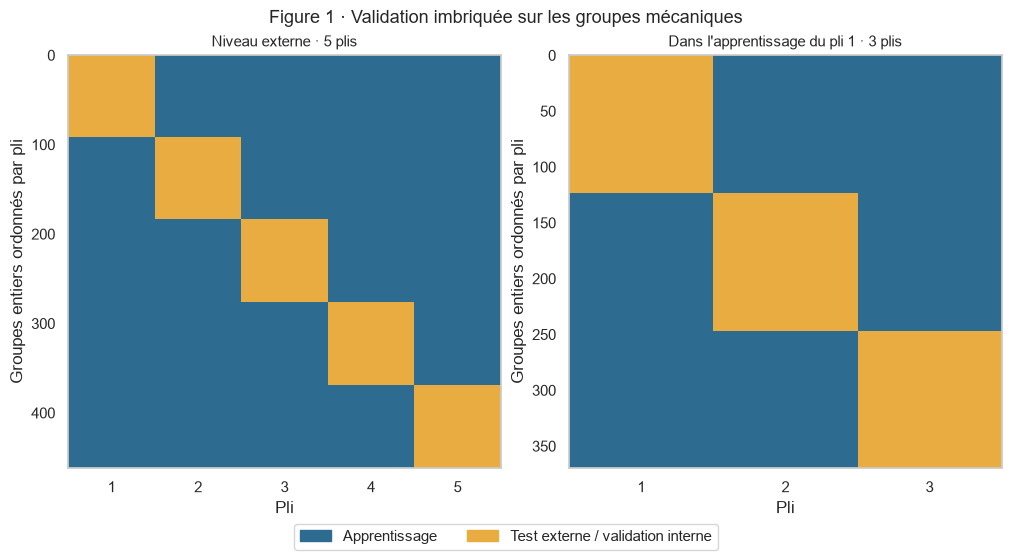

In [103]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Une ligne de la figure représente un groupe de soudure.
outer_group_fold = {}
for fold, (_, te) in enumerate(outer_splits):
    for group in np.unique(G_strength[te]): outer_group_fold[group] = fold
ordered_groups = sorted(outer_group_fold, key=lambda g: (outer_group_fold[g], g))
outer_matrix = np.zeros((len(ordered_groups), 5), dtype=int)
for i, group in enumerate(ordered_groups): outer_matrix[i, outer_group_fold[group]] = 1
train_first, test_first = outer_splits[0]
g_inner = G_strength[train_first]
inner_splits = list(GroupKFold(3).split(X_strength.iloc[train_first], Y_strength[train_first], g_inner))
inner_group_fold = {}
for fold, (_, va) in enumerate(inner_splits):
    for group in np.unique(g_inner[va]): inner_group_fold[group] = fold
inner_order = sorted(inner_group_fold, key=lambda g: (inner_group_fold[g], g))
inner_matrix = np.zeros((len(inner_order), 3), dtype=int)
for i, group in enumerate(inner_order): inner_matrix[i, inner_group_fold[group]] = 1
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), layout="constrained")
colors = ListedColormap(["#2D6B91", "#E9AC41"])
for ax, matrix, title in [(axes[0], outer_matrix, "Niveau externe · 5 plis"),
                           (axes[1], inner_matrix, "Dans l'apprentissage du pli 1 · 3 plis")]:
    ax.imshow(matrix, cmap=colors, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
    ax.set_xticks(range(matrix.shape[1]), range(1, matrix.shape[1]+1))
    ax.grid(False)
    ax.set_xlim(-0.5, matrix.shape[1]-0.5)
    ax.set_xlabel("Pli")
    ax.set_ylabel("Groupes entiers ordonnés par pli")
    ax.set_title(title, fontsize=11)
fig.legend(handles=[mpatches.Patch(color="#2D6B91", label="Apprentissage"),
                    mpatches.Patch(color="#E9AC41", label="Test externe / validation interne")],
           loc="outside lower center", ncol=2)
fig.suptitle("Figure 1 · Validation imbriquée sur les groupes mécaniques", fontsize=13)
plt.show()

## 5.4 Choix de la méthode semi-supervisée

Le CM8 présente notamment le pseudo-étiquetage et les méthodes par graphe. La bibliographie retenue comprend la régularisation de variété de **Belkin et al. (2006)** [B1], les fonctions harmoniques sur graphe de **Zhu et al. (2003)** [B2] et la synthèse de **van Engelen et Hoos (2020)** [B3]. Les références complètes figurent à la fin du notebook.

Nous choisissons une régression régularisée par graphe pour conserver les sorties continues de Nico. Le pseudo-étiquetage demanderait de définir une confiance sur des valeurs en MPa ou en %, alors que les outils `SelfTrainingClassifier` et `LabelSpreading` sont conçus pour des classes.

L’idée est de pénaliser des prédictions très différentes pour des soudures proches dans l’espace des entrées. Les lignes non étiquetées contribuent à cette structure de voisinage. La distance reste toutefois dépendante des catégories, des indicateurs de manque et de la distribution des alliages : des points proches numériquement ne sont pas nécessairement proches du point de vue métallurgique. Nous calculons donc des témoins pour distinguer l’effet de la régularisation et celui des données non étiquetées.

## 5.5 Régression sur graphe

Le prétraitement est ajusté sur les lignes étiquetées d’apprentissage, puis appliqué à ces lignes et aux entrées non étiquetées admissibles. Une carte Nyström de noyau RBF, ajustée elle aussi sur les seules lignes étiquetées, donne une représentation de rang au plus 80, avec γ = 1/d. Le graphe relie les dix plus proches voisins dans l’espace prétraité.

Les poids des arêtes sont exp(−distance²/(2σ²)), où σ est la médiane des distances non nulles. Le graphe est symétrisé par le maximum des deux directions et sa diagonale est nulle. Nous utilisons le laplacien $L=(D-W)/\bar d$, ramené au degré moyen ; ce n’est pas le laplacien normalisé symétrique.

Avec Φ la carte centrée sur l’apprentissage, Y les sorties standardisées et centrées, ℓ le nombre de lignes étiquetées et n le nombre de sommets, nous minimisons :

$$J(B)=\frac{1}{\ell}\|\Phi_LB-Y\|_F^2+\alpha\|B\|_F^2+\frac{\lambda}{n}\operatorname{tr}(B^\top\Phi^\top L\Phi B).$$

Le dernier terme pénalise les variations des prédictions entre voisins. Les coefficients sont obtenus en résolvant :

$$\left(\frac{\Phi_L^\top\Phi_L}{\ell}+\alpha I+\frac{\lambda}{n}\Phi^\top L\Phi\right)B=\frac{\Phi_L^\top Y}{\ell}.$$

Comme α > 0, le système est positif défini. La constante correspond à la moyenne des sorties d’apprentissage ; elle ne change pas les différences du graphe. Une nouvelle soudure est prédite avec la carte et les coefficients déjà appris, sans être ajoutée au graphe.

Les grilles internes sont α ∈ {0,001 ; 0,01 ; 0,1} et λ ∈ {0,01 ; 0,1 ; 1}. Le rang, γ et le nombre de voisins sont fixes. Cette implémentation reprend le principe de Belkin et al. dans une approximation à dimension finie ; elle ne reproduit pas exactement LapRLS dans un RKHS complet.

Nous calculons trois variantes sur les mêmes plis :

- `Nystroem_Ridge_control` : λ = 0, sans données non étiquetées ;
- `Graph_labeled_only` : graphe construit sur les seules lignes étiquetées ;
- `Graph_semi_supervised` : graphe construit avec les entrées non étiquetées admissibles.

Chaque variante règle ses paramètres en interne. Avec λ = 0, fournir des entrées non étiquetées ne change ni la carte ni le modèle. La classe `GraphRegressor` est définie dans les cellules ci-dessus.

In [104]:
# Exemple sur les données d’apprentissage du premier pli.
tr, te = outer_splits[0]
held_out_groups = set(G_strength[te])
pool_ids = np.asarray(strength_spec["unlabeled"])
u_ids = np.asarray([i for i in pool_ids
                    if df_ml.loc[i, "Validation_Group"] not in held_out_groups])
assert set(df_ml.loc[u_ids, "Validation_Group"]).isdisjoint(held_out_groups)
pp_demo = make_preprocessor_ml(features_ml)
Z_L_demo = pp_demo.fit_transform(X_strength.iloc[tr]).to_numpy()
Z_U_demo = pp_demo.transform(df_ml.loc[u_ids, features_ml]).to_numpy()
target_scaler_demo = StandardScaler().fit(Y_strength[tr])
with threadpool_limits(limits=1):
    graph_demo = GraphRegressor(alpha=0.01, graph_lambda=0.1).fit(
        Z_L_demo, target_scaler_demo.transform(Y_strength[tr]), X_unlabeled=Z_U_demo)
print("Paramètres de démonstration, non sélectionnés pour un score : α=0.01, λ=0.1")
print("Lignes L :", graph_demo.n_labeled_, "— lignes U admissibles :", graph_demo.n_unlabeled_)
print("Résidu du système :", graph_demo.normal_equation_residual_)
display(pd.DataFrame([graph_demo.graph_info_]))
assert graph_demo.normal_equation_residual_ < 1e-6

Paramètres de démonstration, non sélectionnés pour un score : α=0.01, λ=0.1
Lignes L : 532 — lignes U admissibles : 879
Résidu du système : 7.165773235630194e-17


,n_nodes,n_edges,n_components,components_without_label,sigma,penalty_norm
0,1411,8975,15,4,1.449268,0.002817


L’audit compte les composantes du graphe qui ne contiennent aucun exemple étiqueté. Le modèle peut y produire une prédiction, mais il ne dispose pas d’une mesure locale pour l’étayer. Les indices des entrées non étiquetées sont enregistrés après exclusion des groupes de validation et de test.

## 5.6 Énergie Charpy

La température Charpy est une condition d’essai connue. Nous prédisons l’énergie en conservant les valeurs 100 J et 28 J dans l’expérience principale : leur caractère fictif n’est pas confirmé par la [documentation MAP](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html).

Une analyse de sensibilité retire les valeurs 100 J, sans les transformer en lignes non étiquetées. Elle conserve **523 lignes et 200 groupes**, contre 879 lignes et 328 groupes au départ. La moyenne et la forêt aléatoire sont calculées avec le même protocole 5 × 3. Les valeurs 28 J restent présentes. Comme cette analyse change la population étudiée et les plis, ses scores ne sont pas directement comparables à ceux de l’expérience principale.

## 5.7 Résultats enregistrés

Les sorties du calcul complet sont conservées dans ce notebook. Les cellules suivantes les chargent dans les tables Python sans relancer les modèles. Pour recalculer, passer `RECOMPUTE` à `True` ; l’exécution peut prendre plusieurs minutes.

La table `results_ml["inner_search.csv"]` contient les essais de paramètres et leurs erreurs internes. La table `results_ml["selected_parameters.csv"]` donne les réglages retenus dans chaque pli. Les scores externes n’ont pas servi à modifier les grilles, et aucun modèle final n’est choisi ici.

In [105]:
RECOMPUTE = True
if RECOMPUTE or not results_ml:
    run_experiments(root=ROOT, quick=False)

metadata = results_ml["run_metadata.json"]
assert metadata["status"] == "complete" and not metadata["quick_smoke_only"]
assert (metadata["outer_folds"], metadata["inner_folds"]) == (5, 3)
print("Exécution complète 5 × 3 confirmée.")
print("Python", metadata["python"], "— scikit-learn", metadata["scikit_learn"])
print("Durée machine mesurée :", round(metadata["total_seconds"], 1), "secondes")

oof = results_ml["oof_predictions.csv"]
folds = results_ml["fold_assignments.csv"]
metrics_raw = results_ml["metrics_by_fold.csv"]
audit = results_ml["semi_supervised_audit.csv"]
selected = results_ml["selected_parameters.csv"]
display(oof.groupby(["task", "model"]).agg(
    lignes=("row_id", "nunique"), cibles=("target", "nunique"),
    plis=("outer_fold", "nunique")).reset_index())

strength: 665 lignes, 462 groupes
  pli 1/5 Dummy_mean: exécuté (0.1s)
  pli 1/5 OLS: exécuté (0.2s)
  pli 1/5 Ridge: exécuté (0.6s)
  pli 1/5 KNN: exécuté (0.9s)
  pli 1/5 SVR_RBF: exécuté (1.7s)
  pli 1/5 DecisionTree: exécuté (0.9s)
  pli 1/5 Bagging: exécuté (4.0s)
  pli 1/5 RandomForest: exécuté (3.6s)
  pli 1/5 ExtraTrees: exécuté (3.1s)
  pli 1/5 Nystroem_Ridge_control: exécuté, U=0
  pli 1/5 Graph_labeled_only: exécuté, U=0
  pli 1/5 Graph_semi_supervised: exécuté, U=879
  pli 2/5 Dummy_mean: exécuté (0.2s)
  pli 2/5 OLS: exécuté (0.2s)
  pli 2/5 Ridge: exécuté (0.5s)
  pli 2/5 KNN: exécuté (1.0s)
  pli 2/5 SVR_RBF: exécuté (1.7s)
  pli 2/5 DecisionTree: exécuté (0.8s)
  pli 2/5 Bagging: exécuté (4.0s)
  pli 2/5 RandomForest: exécuté (4.1s)
  pli 2/5 ExtraTrees: exécuté (3.6s)
  pli 2/5 Nystroem_Ridge_control: exécuté, U=0
  pli 2/5 Graph_labeled_only: exécuté, U=0
  pli 2/5 Graph_semi_supervised: exécuté, U=873
  pli 3/5 Dummy_mean: exécuté (0.1s)
  pli 3/5 OLS: exécuté (0.1s)

,task,model,lignes,cibles,plis
0,charpy,Bagging,879,1,5
1,charpy,DecisionTree,879,1,5
2,charpy,Dummy_mean,879,1,5
3,charpy,ExtraTrees,879,1,5
4,charpy,KNN,879,1,5
5,charpy,OLS,879,1,5
6,charpy,RandomForest,879,1,5
7,charpy,Ridge,879,1,5
8,charpy,SVR_RBF,879,1,5
9,charpy_without_100_sensitivity,Dummy_mean,523,1,5


### Fichiers pour la comparaison

`oof_predictions.csv` rassemble les observations et les prédictions, avec une ligne par cible, modèle et essai. `metrics_by_fold.csv` donne MAE, RMSE et R² séparément par cible, avec des poids par ligne (`rows`) ou par groupe (`groups`). `metrics_oof_pooled.csv` calcule les scores sur l’ensemble des prédictions OOF : ils peuvent différer de la moyenne des scores des cinq plis.

Ces fichiers permettent de comparer les approches sur les mêmes observations. Le choix argumenté des métriques, l’analyse des erreurs et la conclusion feront partie de la dernière contribution. Les cinq plis ne sont pas des répétitions indépendantes : leur dispersion ne constitue pas, à elle seule, un intervalle de confiance.

In [106]:
# Réglages retenus dans chaque pli et structure des graphes.
display(selected[["task", "outer_fold", "model", "parameters"]])
display(audit.loc[audit.inner_fold.eq(0) & audit.model.eq("Graph_semi_supervised"),
                  ["outer_fold", "n_labeled_train", "n_unlabeled", "n_nodes", "n_edges",
                   "n_components", "components_without_label", "group_overlap_outer_test"]])
print("Schéma des prédictions :", list(oof.columns))
print("Schéma des scores bruts :", list(metrics_raw.columns))

,task,outer_fold,model,parameters
0,strength,1,Dummy_mean,{}
1,strength,1,OLS,{}
2,strength,1,Ridge,"{""alpha"": 10}"
3,strength,1,KNN,"{""n_neighbors"": 3, ""weights"": ""distance""}"
4,strength,1,SVR_RBF,"{""estimator__C"": 100, ""estimator__epsilon"": 0.2}"
...,...,...,...,...
110,charpy_without_100_sensitivity,3,RandomForest,"{""max_features"": 0.5, ""min_samples_leaf"": 2}"
111,charpy_without_100_sensitivity,4,Dummy_mean,{}
112,charpy_without_100_sensitivity,4,RandomForest,"{""max_features"": 0.5, ""min_samples_leaf"": 2}"
113,charpy_without_100_sensitivity,5,Dummy_mean,{}


,outer_fold,n_labeled_train,n_unlabeled,n_nodes,n_edges,n_components,components_without_label,group_overlap_outer_test
11,1,532,879,1411.0,8975.0,15.0,4.0,0
23,2,532,873,1405.0,8729.0,21.0,6.0,0
35,3,532,848,1380.0,8738.0,14.0,5.0,0
47,4,532,817,1349.0,8519.0,16.0,5.0,0
59,5,532,868,1400.0,8839.0,16.0,4.0,0


Schéma des prédictions : ['task', 'model', 'outer_fold', 'row_id', 'group', 'target', 'y_true', 'y_pred']
Schéma des scores bruts : ['task', 'model', 'outer_fold', 'target', 'weighting', 'RMSE', 'MAE', 'R2']


## 5.8 Vérification des prédictions et des plis

Nous vérifions qu’une seule prédiction existe pour chaque ligne, cible et modèle, et que toutes les lignes attendues sont présentes. Nous contrôlons aussi que chaque groupe et chaque `Weld_ID` reste dans un seul pli externe. Les exclusions du réservoir non étiqueté sont vérifiées à partir des indices enregistrés dans l’audit.

In [107]:
assert not oof.duplicated(["task", "model", "row_id", "target"]).any()
assert np.isfinite(oof[["y_true", "y_pred"]].to_numpy()).all()
for task, assigned in folds.groupby("task"):
    assert assigned.groupby("group").outer_fold.nunique().eq(1).all()
    joined = assigned.merge(df_ml[["Weld_ID"]], left_on="row_id", right_index=True)
    assert joined.groupby("Weld_ID").outer_fold.nunique().eq(1).all()
    for (model, target), predictions in oof[oof.task.eq(task)].groupby(["model", "target"]):
        assert set(predictions.row_id) == set(assigned.row_id)
        assert set(predictions.outer_fold) == {1, 2, 3, 4, 5}
        np.testing.assert_allclose(predictions.y_true.to_numpy(),
                                   df_ml.loc[predictions.row_id, target].to_numpy(float))
for _, rec in audit.iterrows():
    tr_ids = json.loads(rec.train_row_ids)
    va_ids = json.loads(rec.validation_row_ids)
    un_ids = json.loads(rec.unlabeled_row_ids)
    gt, gv, gu = [set(df_ml.loc[ids, "Validation_Group"]) for ids in [tr_ids, va_ids, un_ids]]
    assert gt.isdisjoint(gv) and gu.isdisjoint(gv)
    outer_test_ids = folds.loc[folds.task.eq("strength") & folds.outer_fold.eq(rec.outer_fold), "row_id"]
    assert gu.isdisjoint(set(df_ml.loc[outer_test_ids, "Validation_Group"]))
    assert set(un_ids).issubset(set(strength_spec["unlabeled"]))
print("Contrôles validés : OOF complets, groupes et Weld_ID séparés, réservoir U sans test ni validation.")

Contrôles validés : OOF complets, groupes et Weld_ID séparés, réservoir U sans test ni validation.


## 5.9 Tests

Le test numérique retrouve les équations de Ridge dans la carte Nyström lorsque λ = 0. Dans ce cas, ajouter des entrées non étiquetées ne modifie pas le résultat. Avec λ > 0, ces entrées changent bien la pénalité et les prédictions.

Les 47 cellules de Nico ont été conservées à l’identique. La cellule ci-dessous vérifie directement les propriétés numériques du modèle.

In [108]:
# Vérifier la résolution et l’apport des entrées non étiquetées.
rng_test = np.random.default_rng(25)
x_test = rng_test.normal(size=(32, 4))
y_test = np.column_stack([x_test[:, 0] ** 2, x_test[:, 1] + x_test[:, 0]])
u_test = rng_test.normal(size=(60, 4)) + 0.5
with threadpool_limits(limits=1):
    ridge_test = GraphRegressor(graph_lambda=0, n_components=20).fit(x_test, y_test)
    zero_test = GraphRegressor(graph_lambda=0, n_components=20).fit(x_test, y_test, u_test)
    np.testing.assert_allclose(ridge_test.predict(x_test), zero_test.predict(x_test), atol=1e-12)
    phi_test = ridge_test.map_.transform(x_test) - ridge_test.feature_mean_
    expected_test = np.linalg.solve(phi_test.T @ phi_test / len(x_test) + ridge_test.alpha * np.eye(phi_test.shape[1]),
                                   phi_test.T @ (y_test-y_test.mean(axis=0)) / len(x_test))
    np.testing.assert_allclose(ridge_test.coef_, expected_test, atol=1e-10)
    label_test = GraphRegressor(graph_lambda=0.5, n_components=20).fit(x_test, y_test)
    semi_test = GraphRegressor(graph_lambda=0.5, n_components=20).fit(x_test, y_test, u_test)
    assert np.linalg.norm(semi_test.graph_penalty_ - label_test.graph_penalty_) > 1e-4
    assert np.linalg.norm(semi_test.predict(x_test)-label_test.predict(x_test)) > 1e-4
    assert semi_test.normal_equation_residual_ < 1e-9
print("Tests réussis : résolution Ridge et utilisation effective des données non étiquetées.")

Tests réussis : résolution Ridge et utilisation effective des données non étiquetées.


## 5.10 Suite du projet

Les modèles et leurs résultats sont prêts pour la comparaison : prédictions OOF, réglages, plis et audit du semi-supervisé. Il reste à analyser les performances, justifier les métriques finales, choisir l’approche retenue et formuler les recommandations sur la qualité des soudures.

Le rapport collectif réunira l’analyse de Nico, une synthèse de cette méthode et la comparaison. Il devra respecter les indications du sujet : environ cinq pages, identités et équipe, figures et tableaux cités, bibliographie et Gantt avec les durées réelles.

Pour GitHub, ajouter les cellules de cette partie à la fin du notebook actuel, puis enregistrer un commit avec son propre compte. Si le notebook du dépôt a évolué, conserver ses nouvelles cellules plutôt que le remplacer entièrement. Les références sont regroupées ci-dessous. La validation contrôle notre expérience sur cette base ; elle ne garantit pas les mêmes performances sur des soudures ou des publications très différentes.

## Références


Les références ont été consultées le 7 octobre 2026. Les supports de Myriam Tami, en particulier le CM8 fourni, apportent les hypothèses et le laplacien ; les références ci-dessous étayent l'adaptation à la régression et les outils.

### Articles

**[B1]** Belkin, M., Niyogi, P. et Sindhwani, V. (2006). *Manifold Regularization: A Geometric Framework for Learning from Labeled and Unlabeled Examples*. Journal of Machine Learning Research, 7, 2399–2434. [Article et PDF](https://www.jmlr.org/papers/v7/belkin06a.html), notamment sections 2 et 4.2.

L'article combine risque supervisé et régularisation géométrique à partir des entrées étiquetées et non étiquetées. Son extension à des observations nouvelles motive notre choix inductif. Notre implémentation utilise une carte explicite Nyström et une pénalité quadratique sur ses coefficients. Elle est une adaptation à dimension finie, et non une reproduction exacte de LapRLS dans un RKHS complet. Le rang, le noyau et la normalisation du laplacien sont explicités dans le notebook.

**[B2]** Zhu, X., Ghahramani, Z. et Lafferty, J. (2003). *Semi-Supervised Learning Using Gaussian Fields and Harmonic Functions*. Proceedings of ICML, 912–919. [PDF des auteurs](https://mlg.eng.cam.ac.uk/pub/pdf/ZhuGhaLaf03a.pdf).

Ce travail justifie la représentation des similarités par un graphe et la recherche de fonctions variant peu le long des arêtes. La propagation pure sur un graphe sert de point de départ conceptuel ; nous conservons une fonction de prédiction pour évaluer des soudures nouvelles exclues du graphe d'entraînement.

**[B3]** van Engelen, J. E. et Hoos, H. H. (2020). *A survey on semi-supervised learning*. Machine Learning, 109, 373–440. [DOI](https://doi.org/10.1007/s10994-019-05855-6), [PDF des auteurs](https://ada.liacs.nl/papers/EngHoo19.pdf). Sections 4.1, 8.1 et 9.

Cette synthèse situe self-training, co-training et graphes. Sa section sur la régression indique que les fonctions réelles des méthodes de graphe s'y adaptent directement. Le pseudo-étiquetage demanderait un critère de confiance pour des sorties continues ; le graphe évite d'introduire ce critère. Les données non étiquetées peuvent dégrader les performances lorsque les hypothèses échouent : l'évaluation inclut donc des témoins supervisés. COREG de Zhou et Li (2005) est une alternative identifiée dans cette synthèse, sans être implémentée ici.

### Données et documentation

**[D1]** Cool, T. et Bhadeshia, H. K. D. H. *MAP Data Library — MAP_DATA_WELD*. [Documentation originale](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html). Définition des 44 colonnes, unités, origine bibliographique et sens de `N`. Le document ne désigne pas 100 J ou 28 J comme sentinelles.

**[D2]** Scikit-learn. [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) et [exemple de validation imbriquée](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html). Distinction sélection/évaluation et séparation par groupes.

**[D3]** Scikit-learn. [Semi-supervised learning](https://scikit-learn.org/stable/modules/semi_supervised.html). `SelfTrainingClassifier`, `LabelPropagation` et `LabelSpreading` sont des outils de classification, à ne pas appliquer directement à nos sorties continues.

**[D4]** Scikit-learn. [Kernel approximation](https://scikit-learn.org/stable/modules/kernel_approximation.html). La carte Nyström fournit une représentation de noyau à dimension finie permettant aussi de transformer de nouvelles observations.

Les méthodes sont présentées avec leurs hypothèses dans le notebook. Leur intérêt sur cette base sera étudié à partir des prédictions OOF.
